In [1]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from compute_transport import *
from simulate_data import *
from evaluation_metrics import *
from benchmark_scalability import *
import torch
import torch.nn.functional as F
import time
from itertools import product
from typing import Union, List, Dict, Tuple
import json
import pickle

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(20, 10), facecolor='white')

STEP 1: Generating parameter sweeps and elbow curves...

Parameter Selection for 20 Cell Types
Creating dataset...
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Using 50 genes

Running parameter sweep...
  Alpha values: [0.1, 0.5, 1.0, 5.0, 10.0]
  Lambda values: [0.1, 0.5, 1.0, 5.0, 10.0]
  T values: [2, 4, 6, 8, 10]
Starting parameter sweep with 125 combinations...
Progress: 12/125 (9.6%)
Progress: 24/125 (19.2%)
Progress: 36/125 (28.8%)
Progress: 48/125 (38.4%)
Progress: 60/125 (48.0%)
Progress: 72/125 (57.6%)
Progress: 84/125 (67.2%)
Progress: 96/125 (76.8%)
Progress: 108/125 (86.4%)
Progress: 120/125 (96.0%)
Parameter sweep completed in 1.2 seconds!

Generating elbow curves for manua

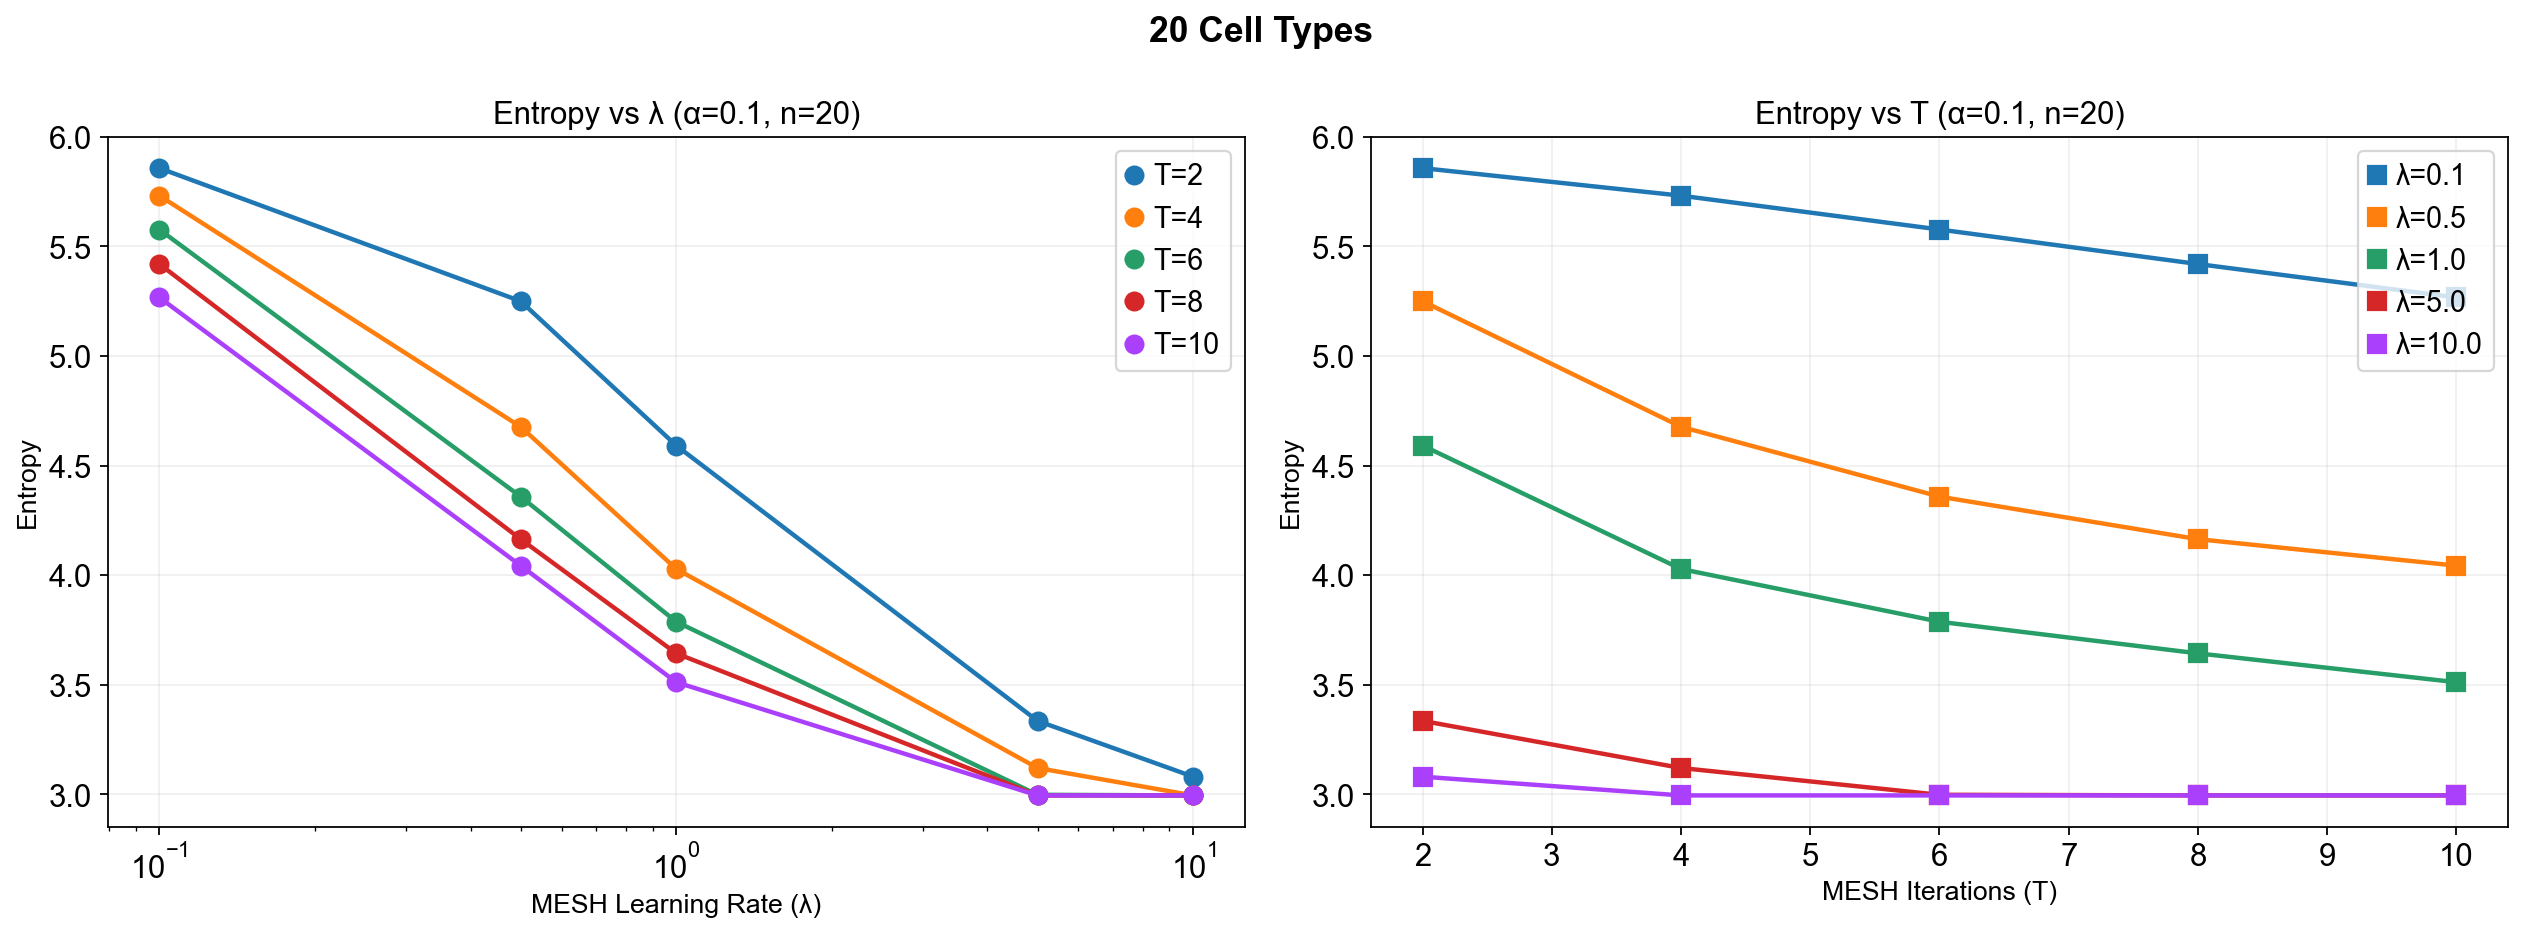

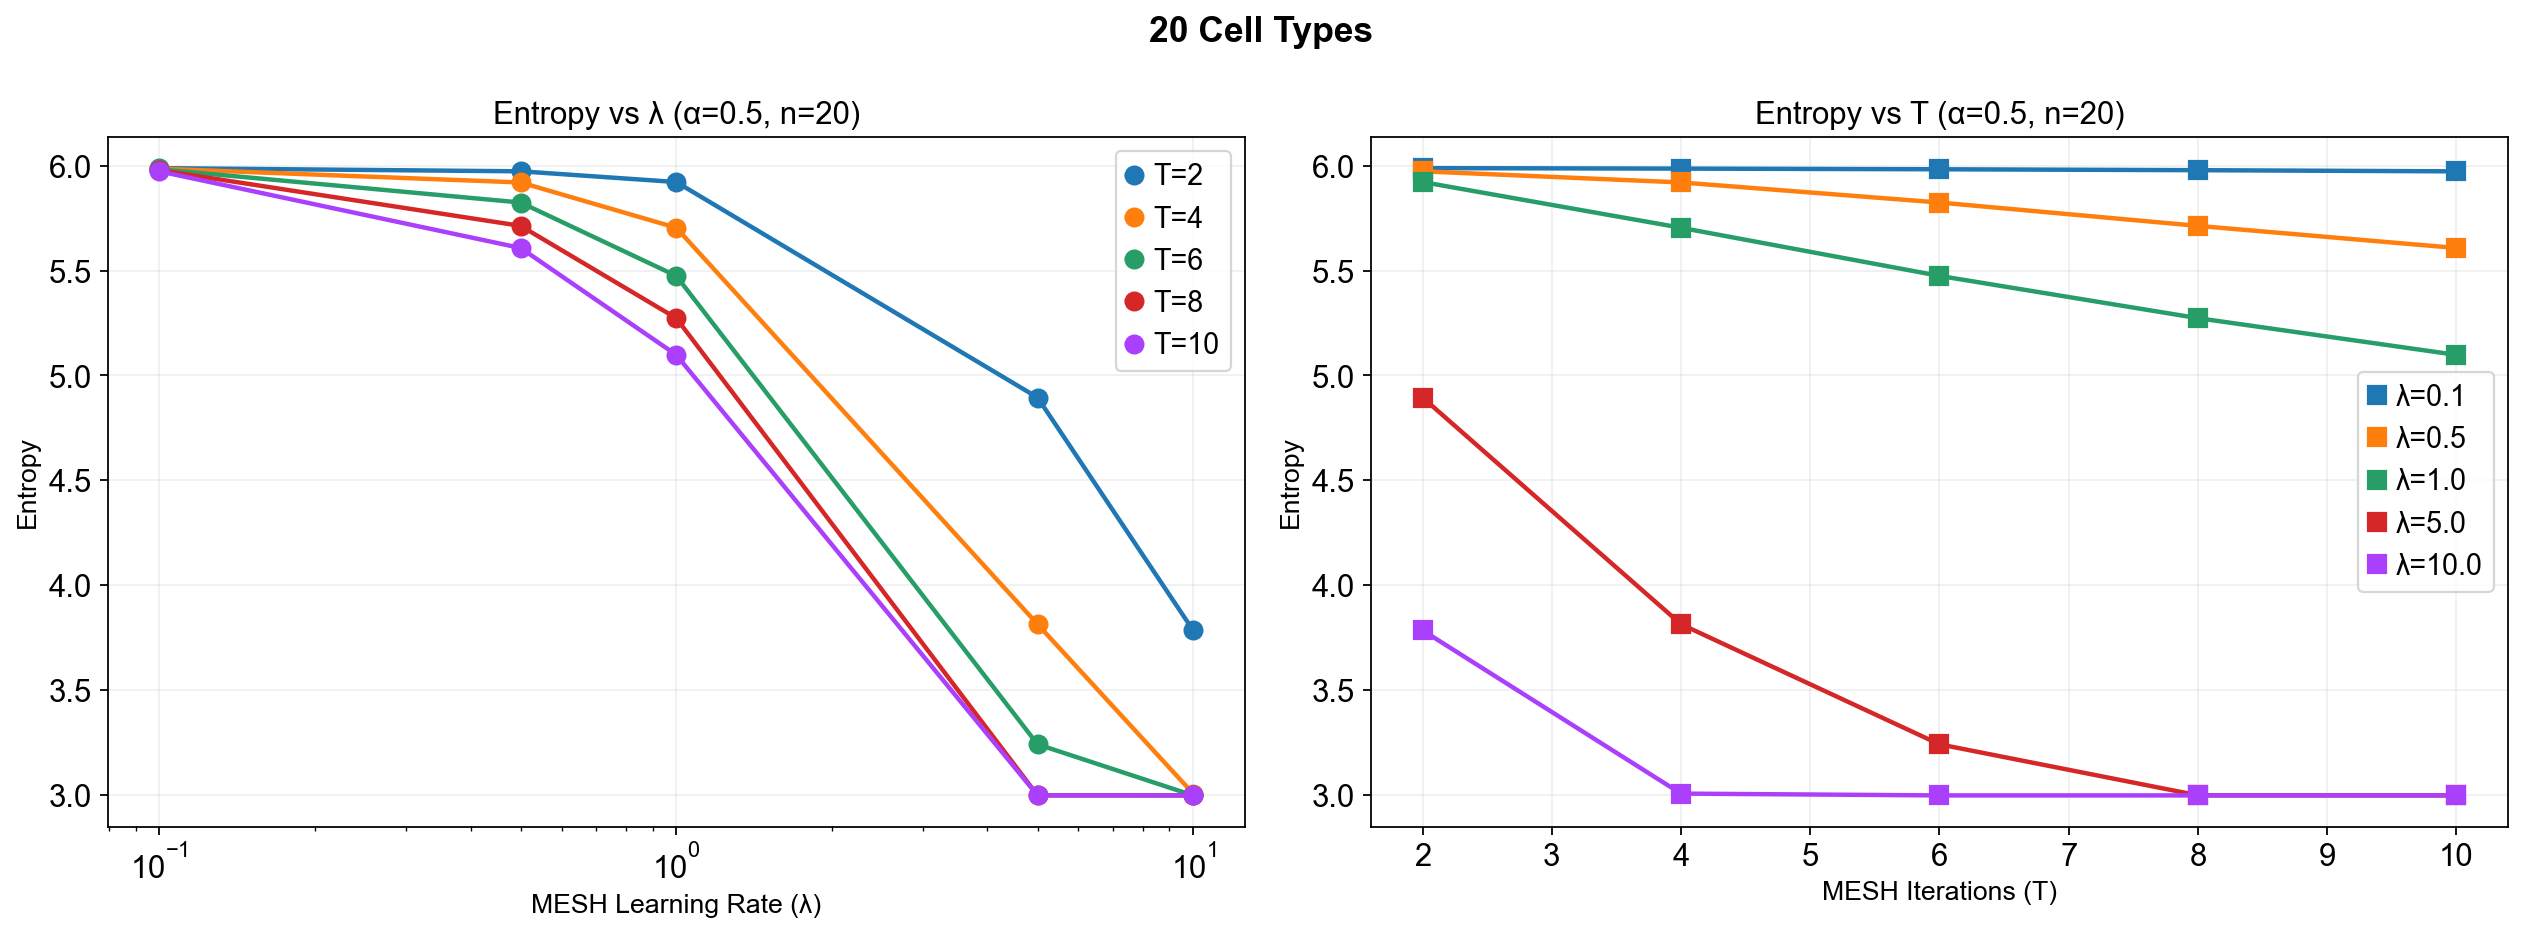

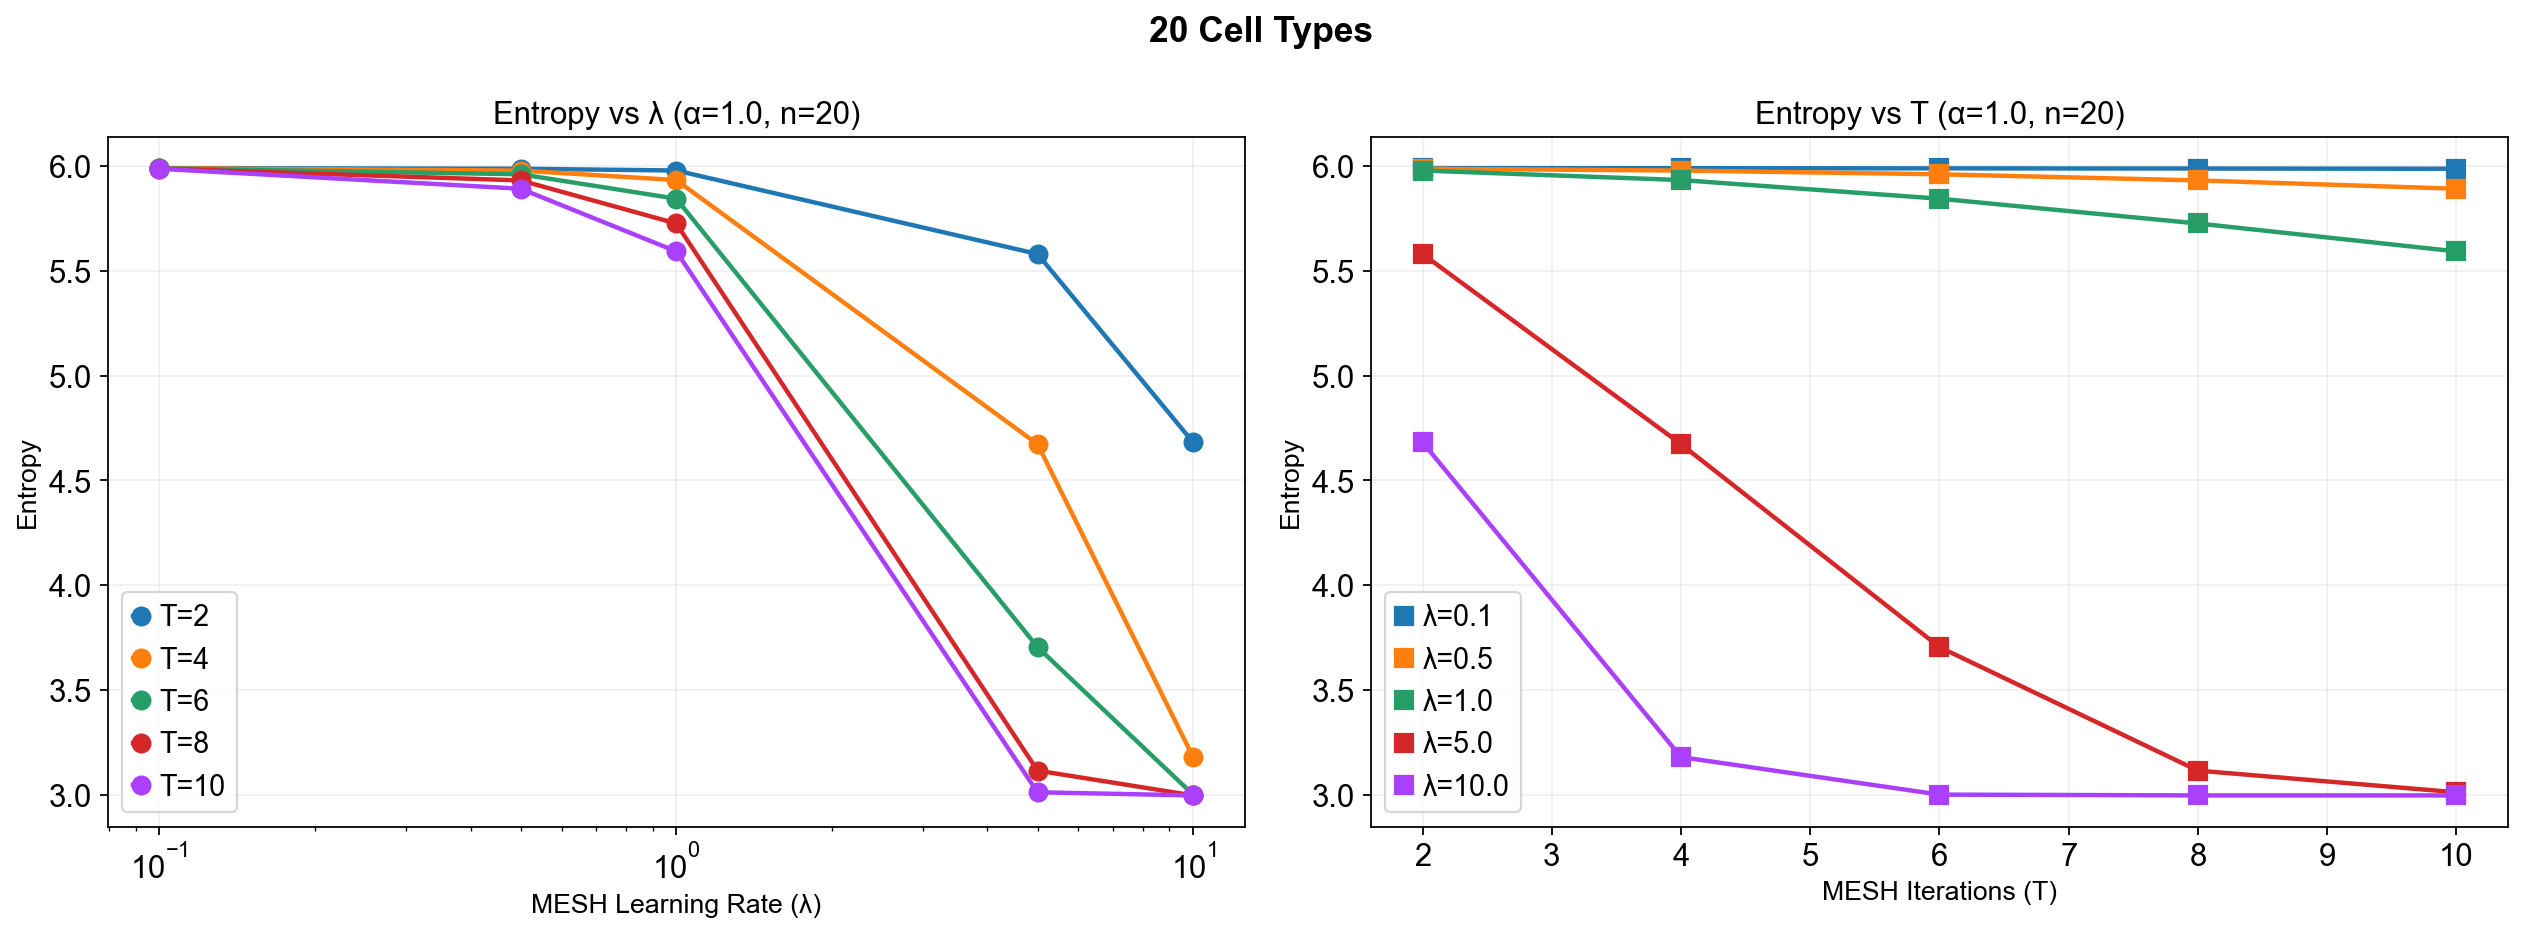

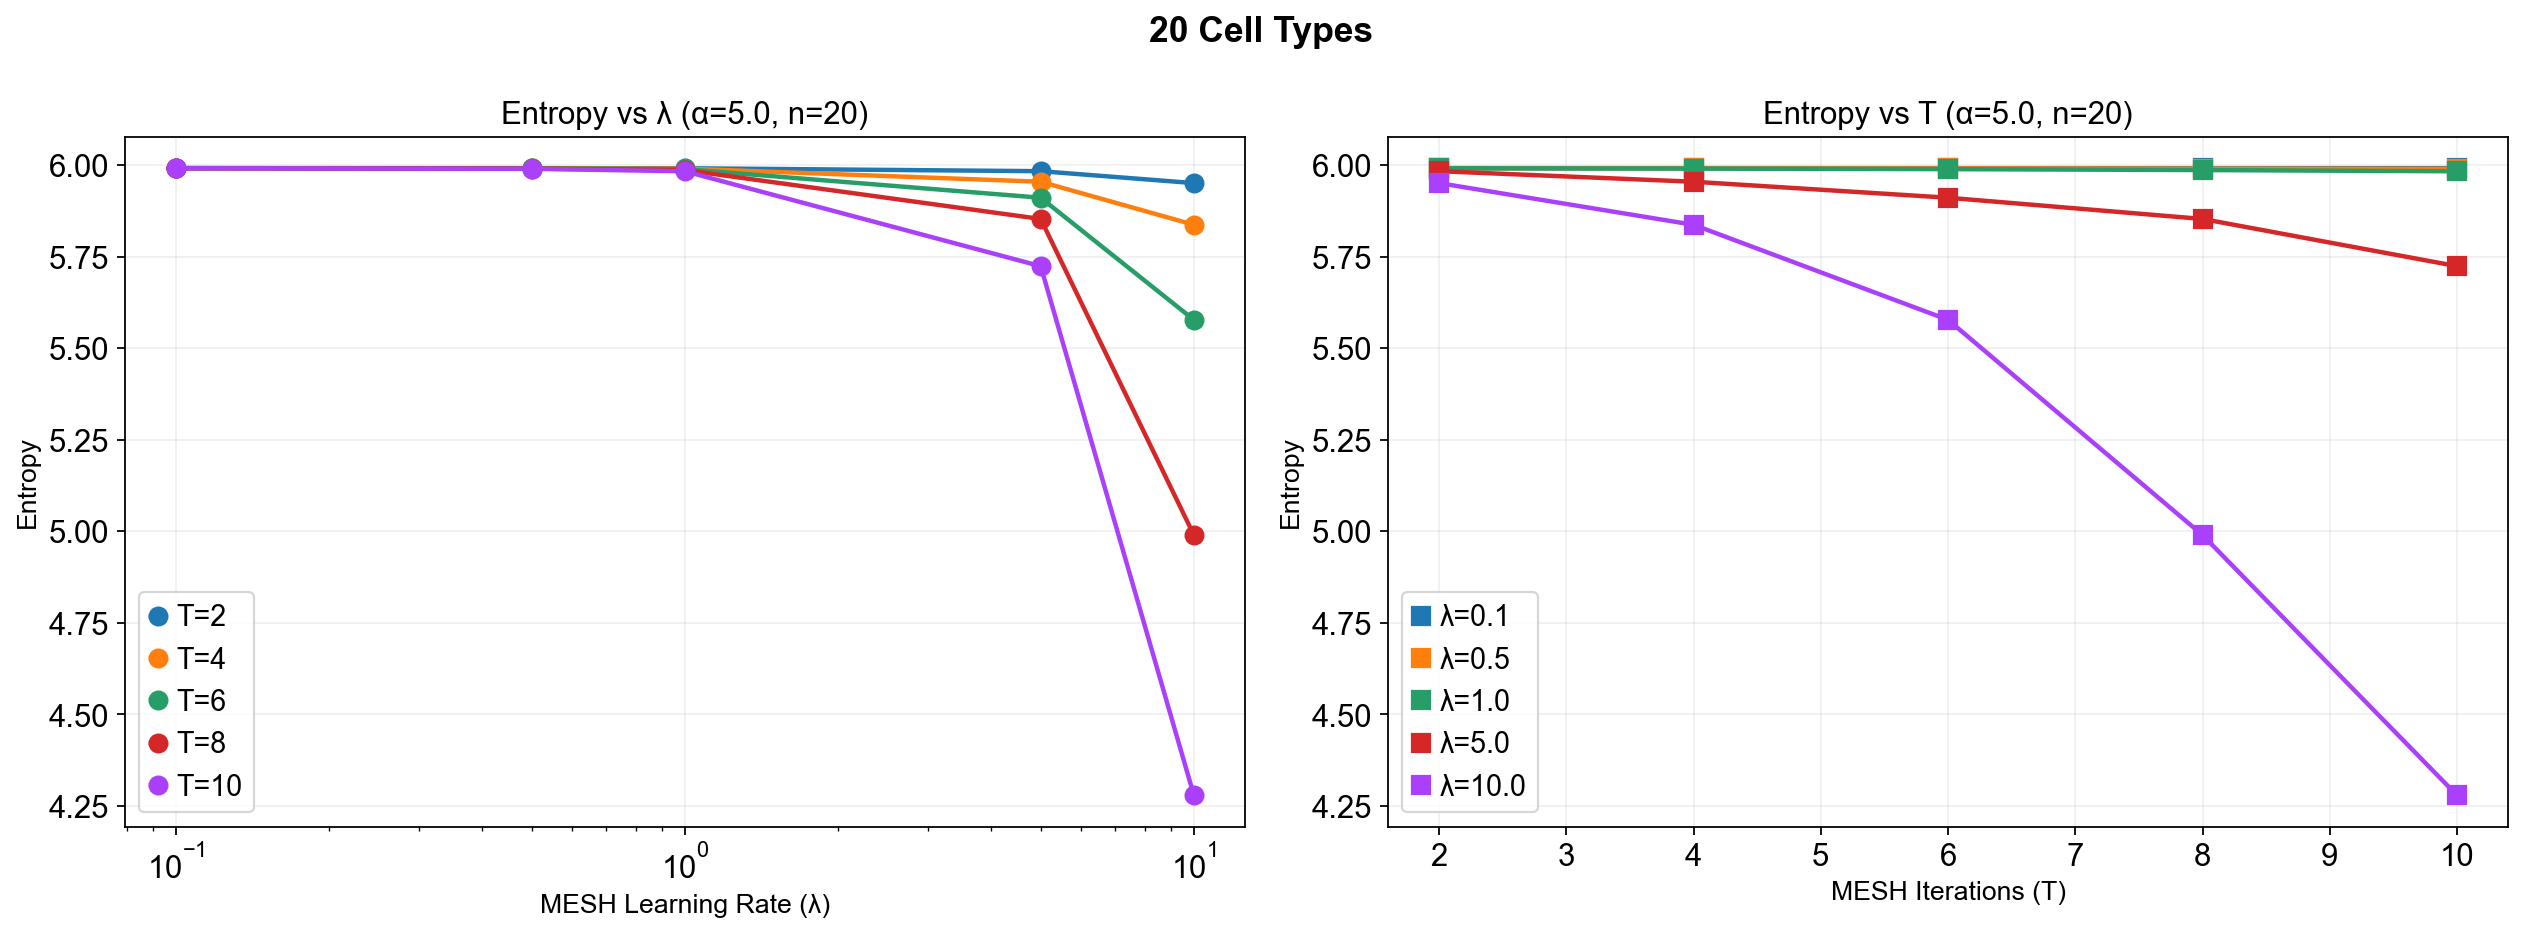

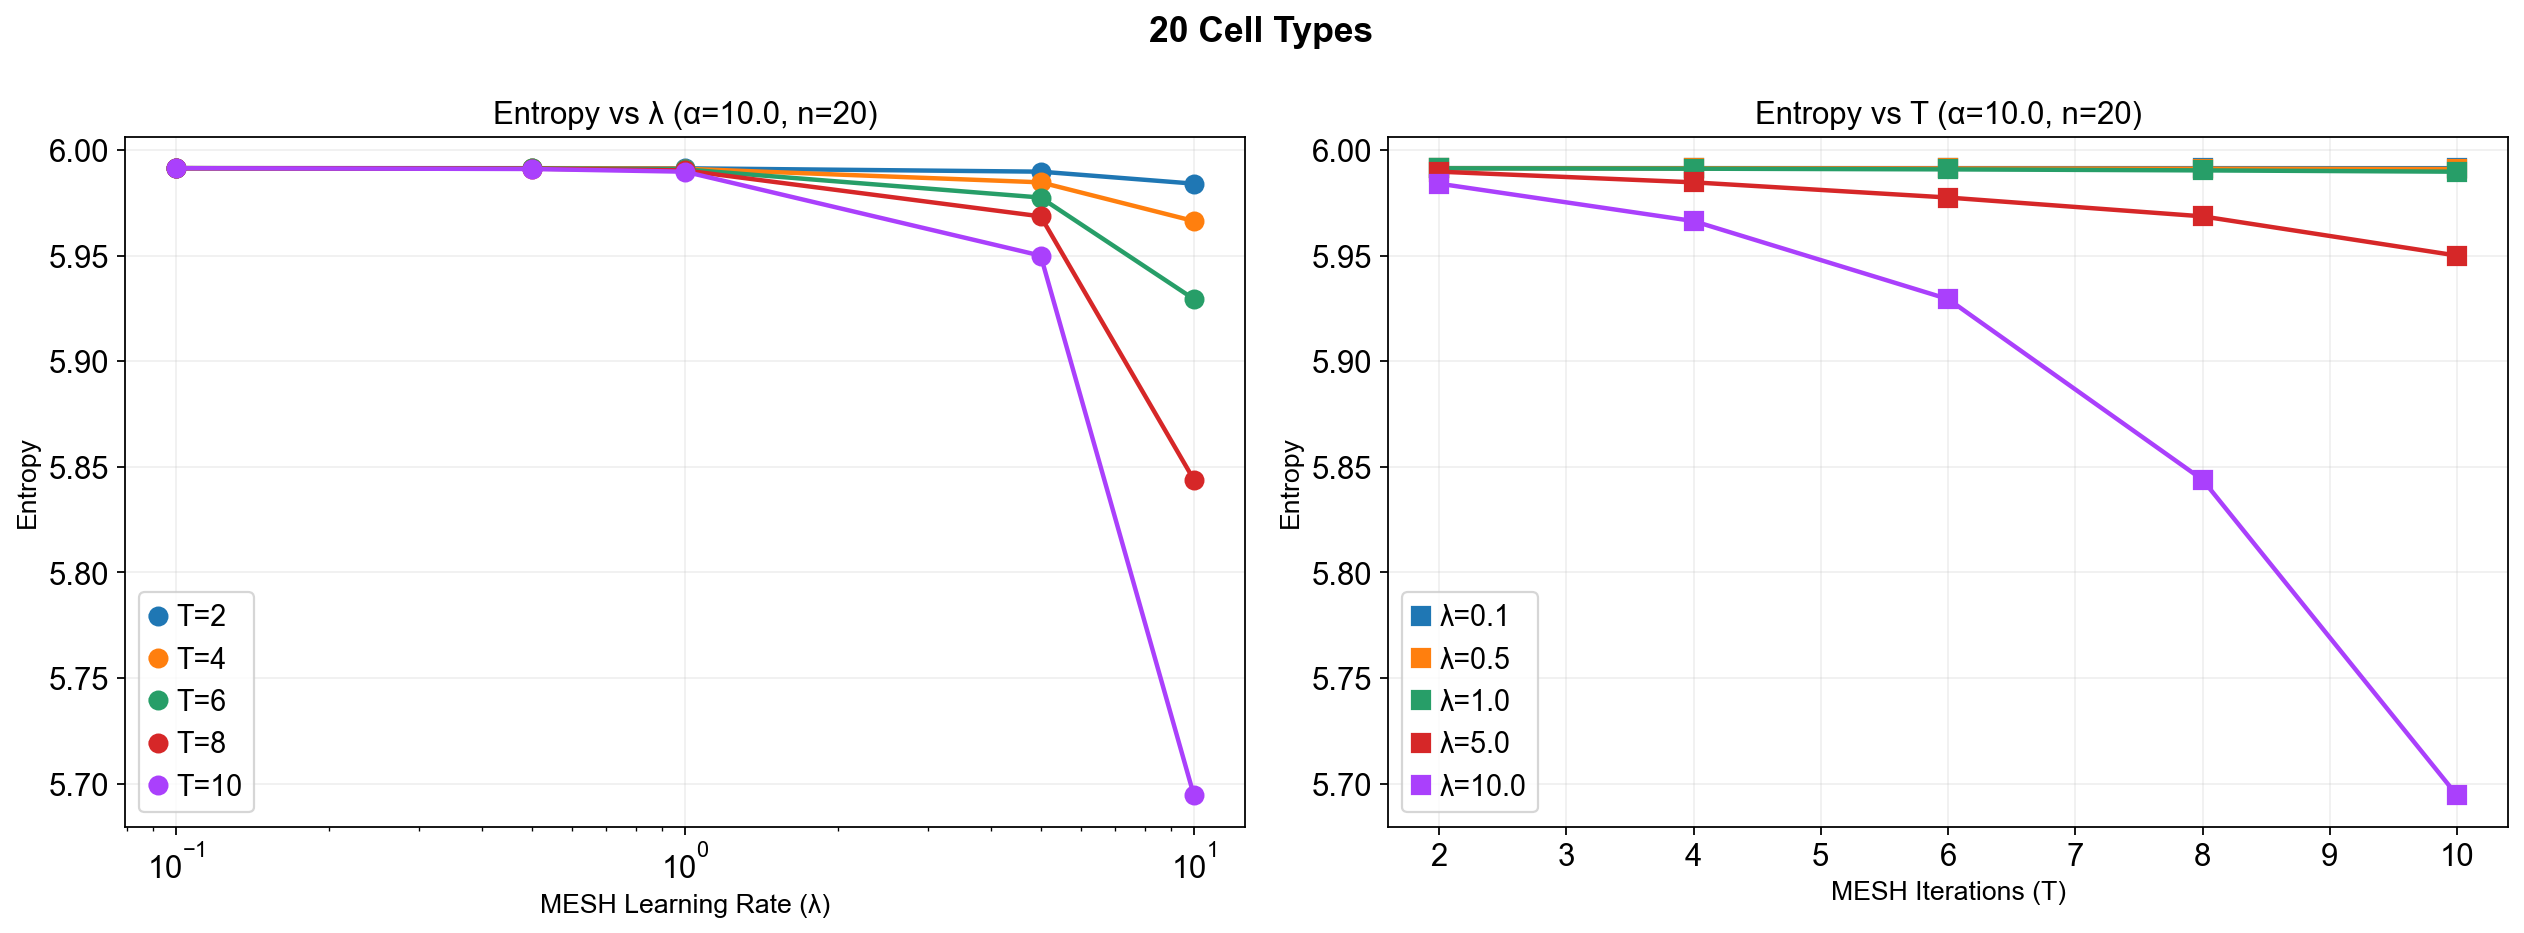


Parameter Selection for 50 Cell Types
Creating dataset...
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Using 50 genes

Running parameter sweep...
  Alpha values: [0.1, 0.5, 1.0, 5.0, 10.0]
  Lambda values: [0.5, 1.0, 5.0, 10.0, 50.0]
  T values: [8, 10, 12, 14, 16]
Starting parameter sweep with 125 combinations...
Progress: 12/125 (9.6%)
Progress: 24/125 (19.2%)
Progress: 36/125 (28.8%)
Progress: 48/125 (38.4%)
Progress: 60/125 (48.0%)
Progress: 72/125 (57.6%)
Progress: 84/125 (67.2%)
Progress: 96/125 (76.8%)
Progress: 108/125 (86.4%)
Progress: 120/125 (96.0%)
Parameter sweep completed in 1.7 seconds!

Generating elbow curves for manual selection...


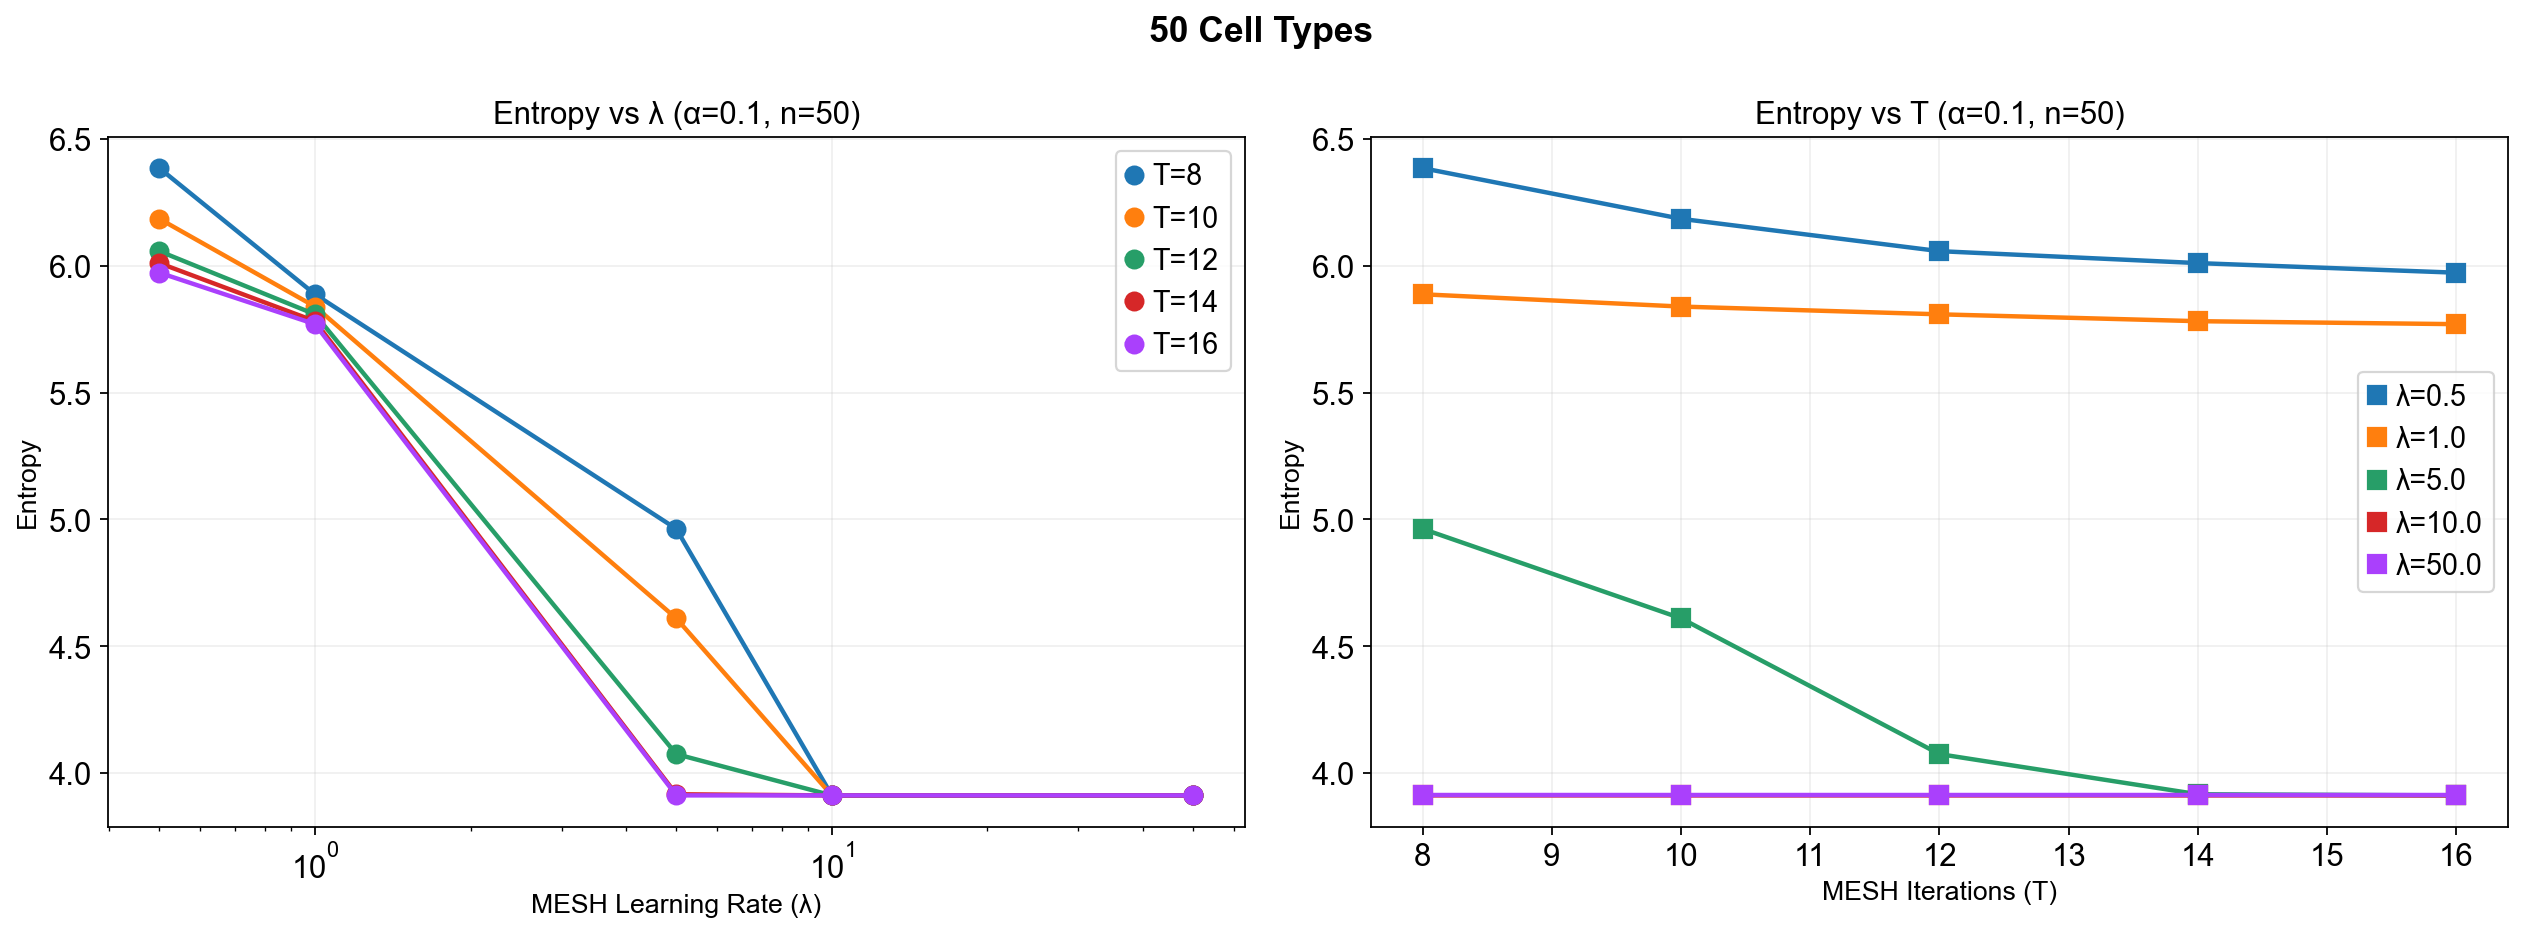

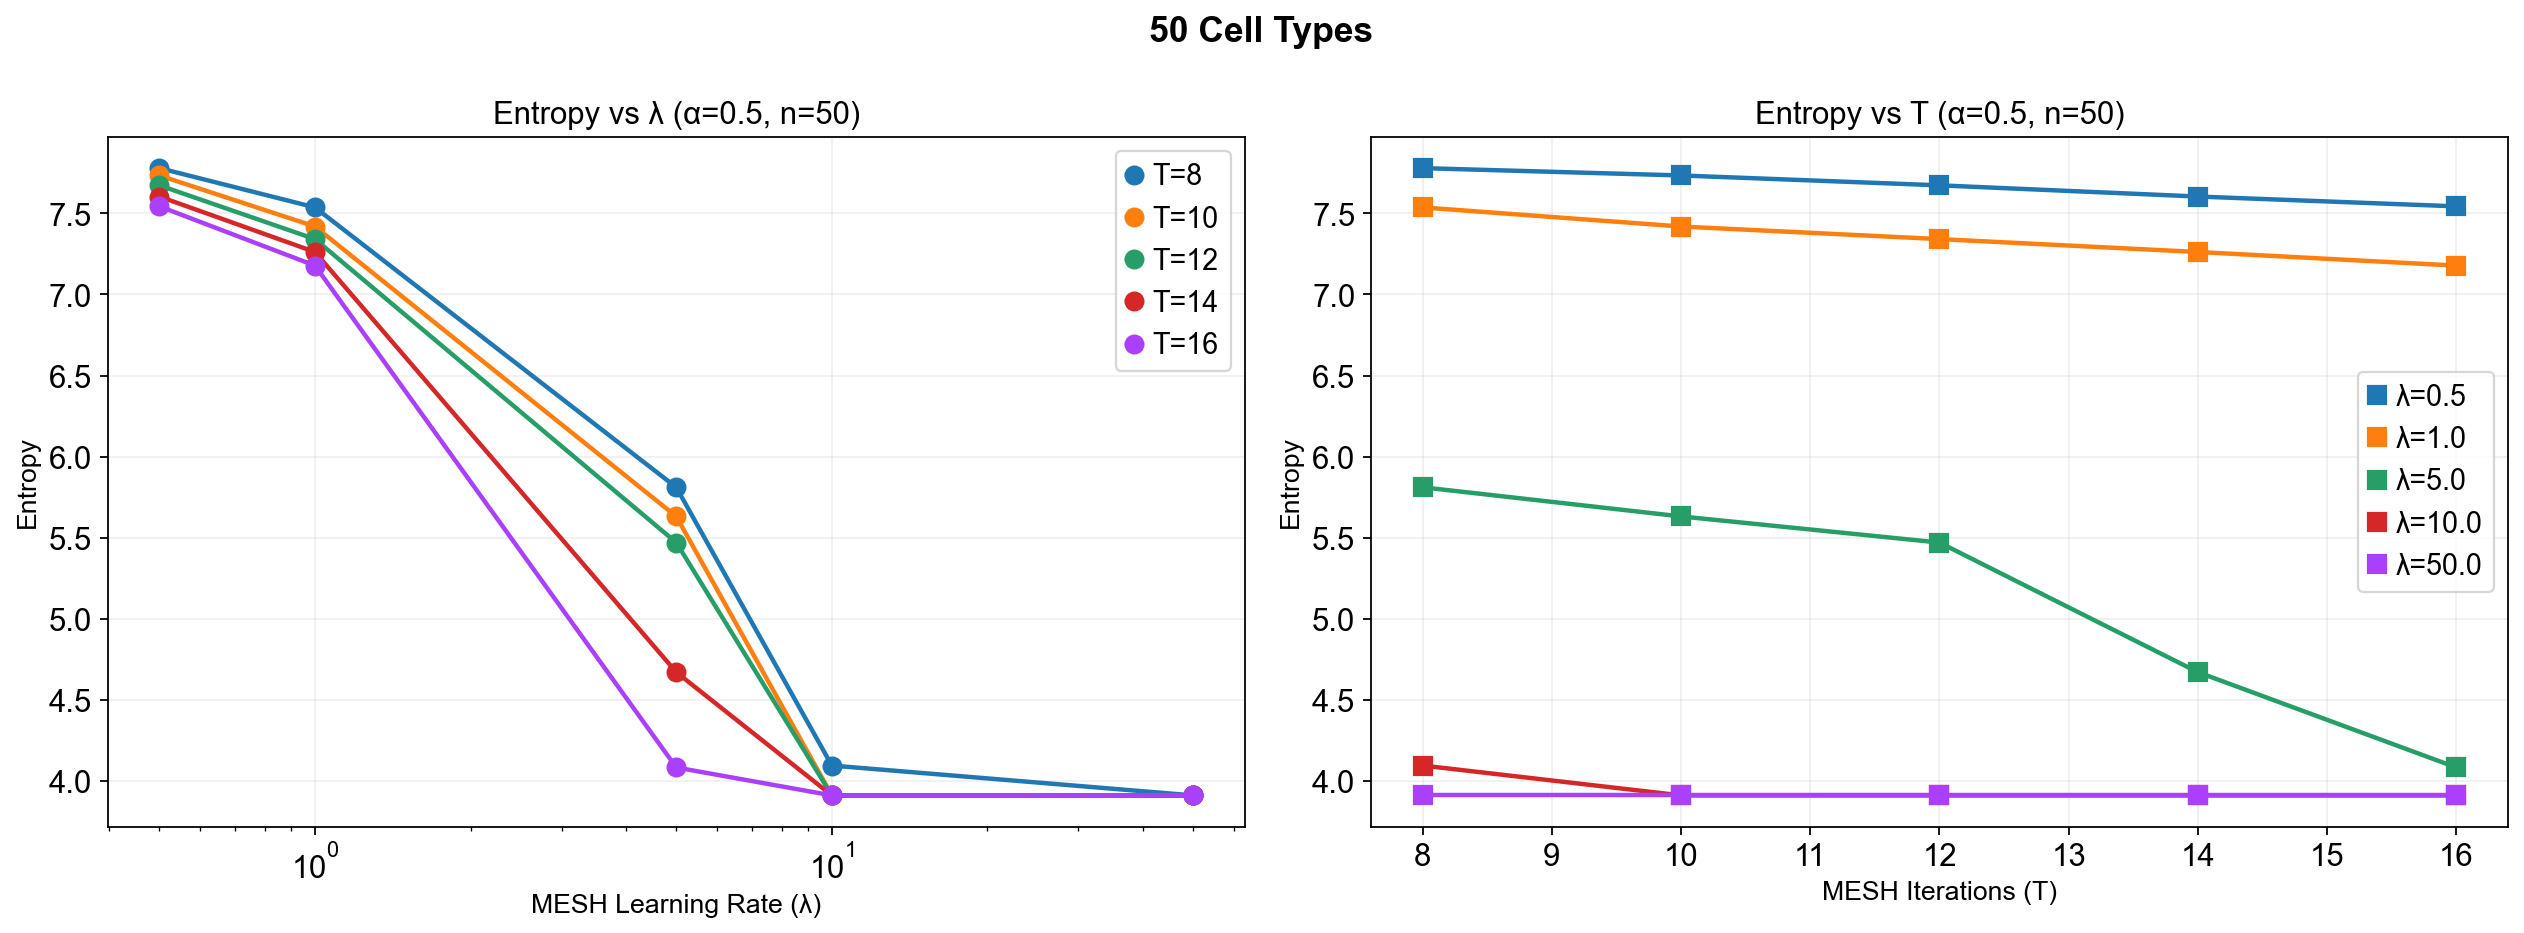

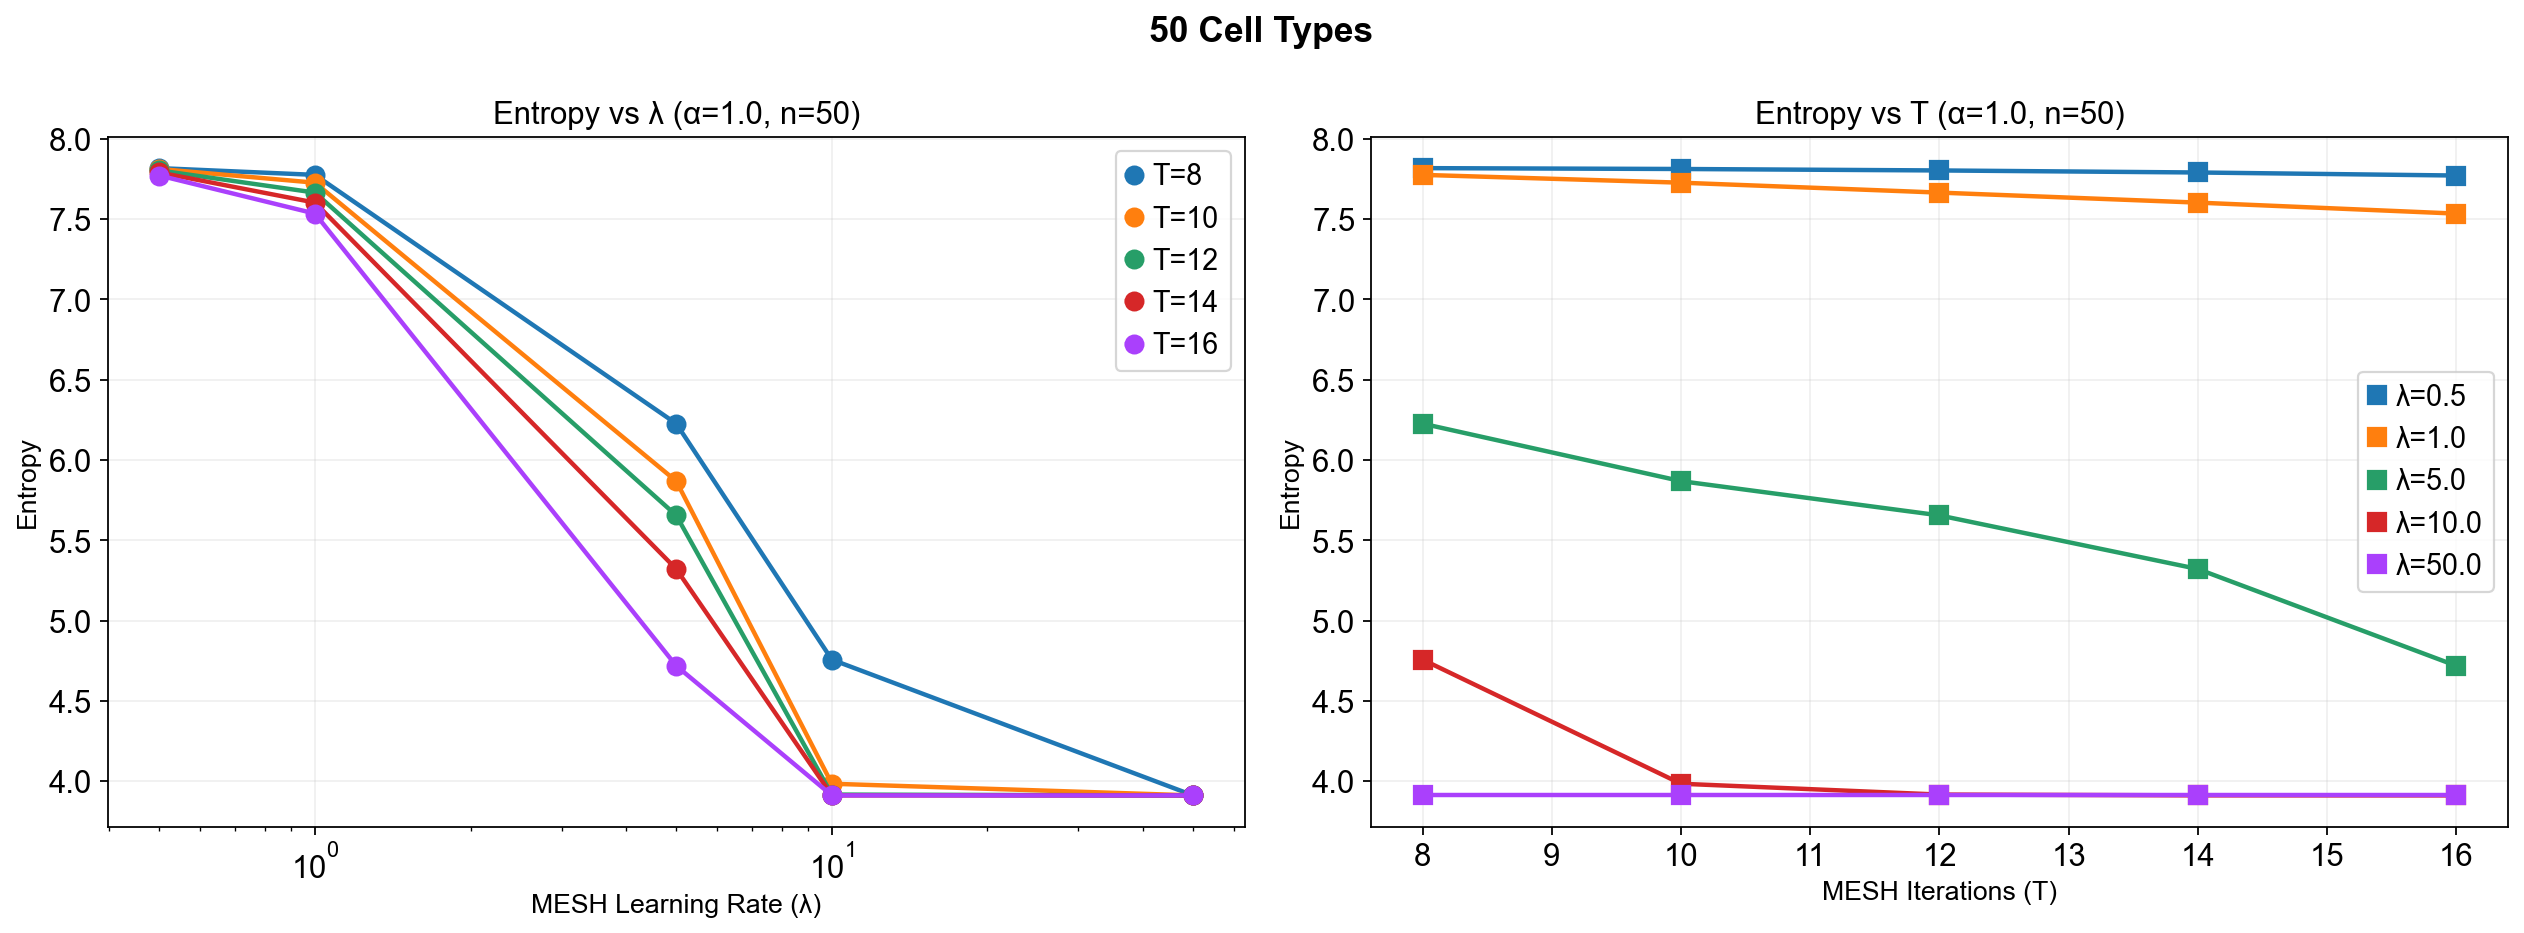

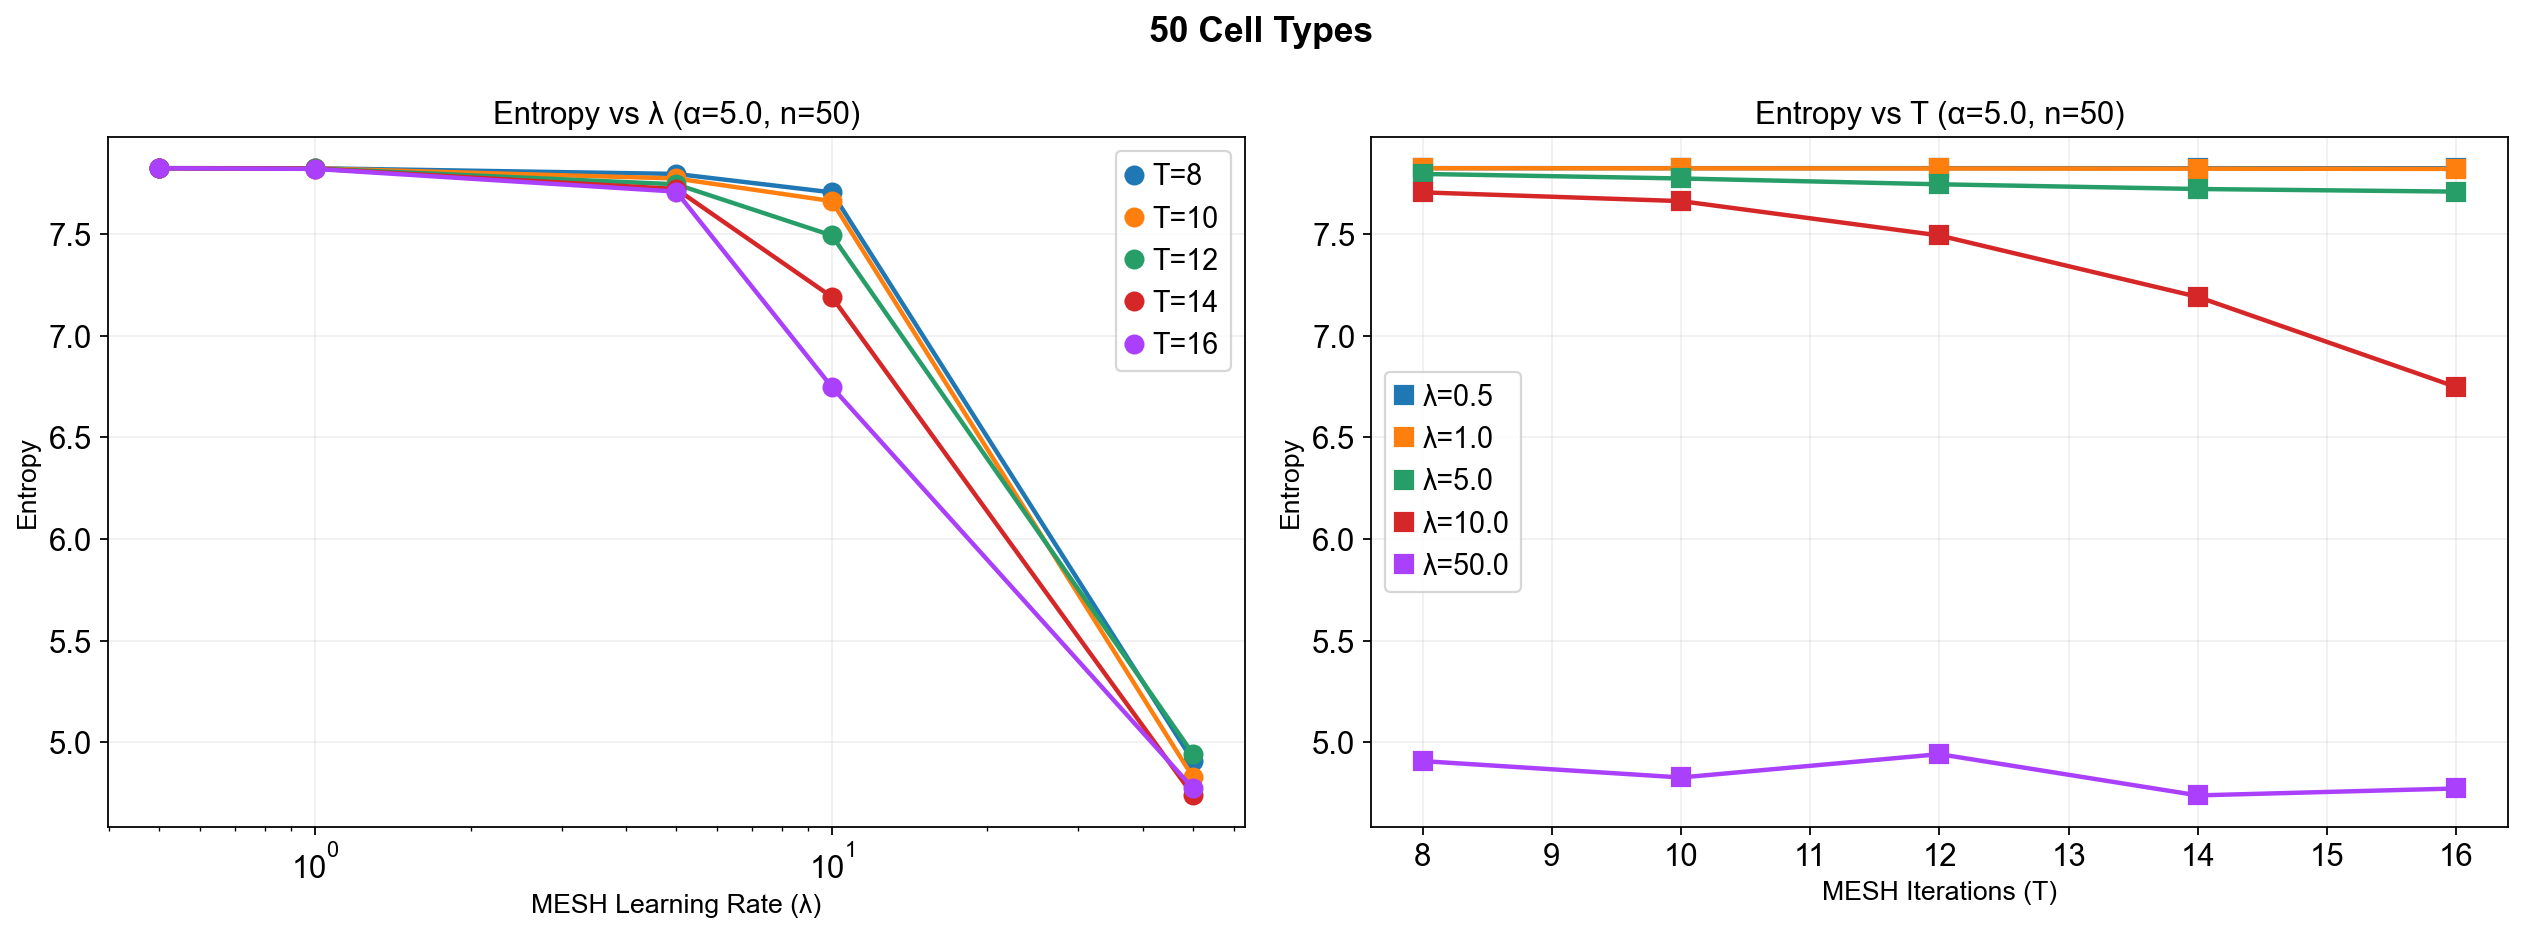

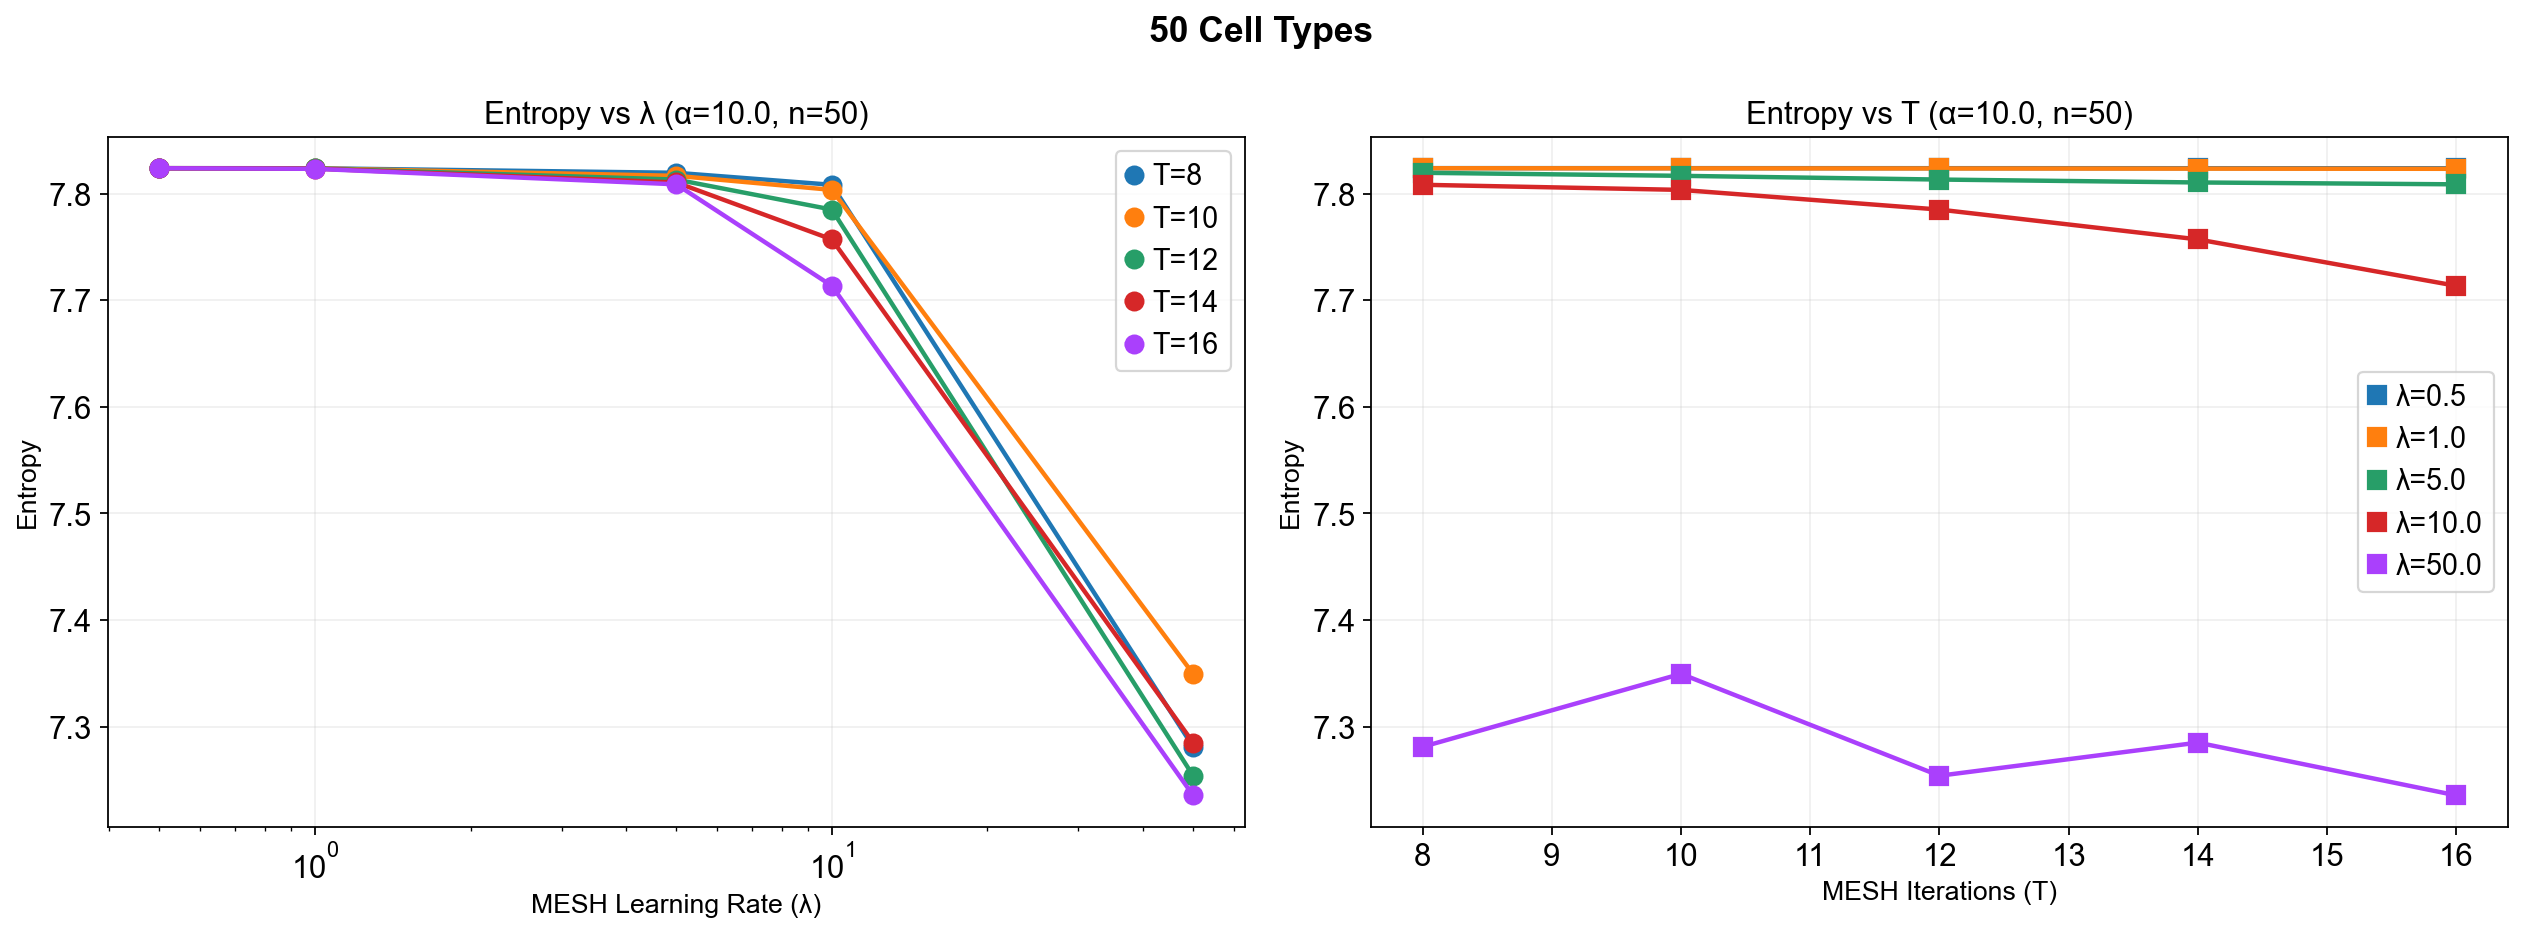


Parameter Selection for 100 Cell Types
Creating dataset...
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Using 100 genes

Running parameter sweep...
  Alpha values: [0.1, 0.5, 1.0, 5.0, 10.0]
  Lambda values: [0.5, 1.0, 5.0, 10.0, 50.0]
  T values: [8, 10, 12, 14, 16]
Starting parameter sweep with 125 combinations...
Progress: 12/125 (9.6%)
Progress: 24/125 (19.2%)
Progress: 36/125 (28.8%)
Progress: 48/125 (38.4%)
Progress: 60/125 (48.0%)
Progress: 72/125 (57.6%)
Progress: 84/125 (67.2%)
Progress: 96/125 (76.8%)
Progress: 108/125 (86.4%)
Progress: 120/125 (96.0%)
Parameter sweep completed in 3.0 seconds!

Generating elbow curves for manual selection...


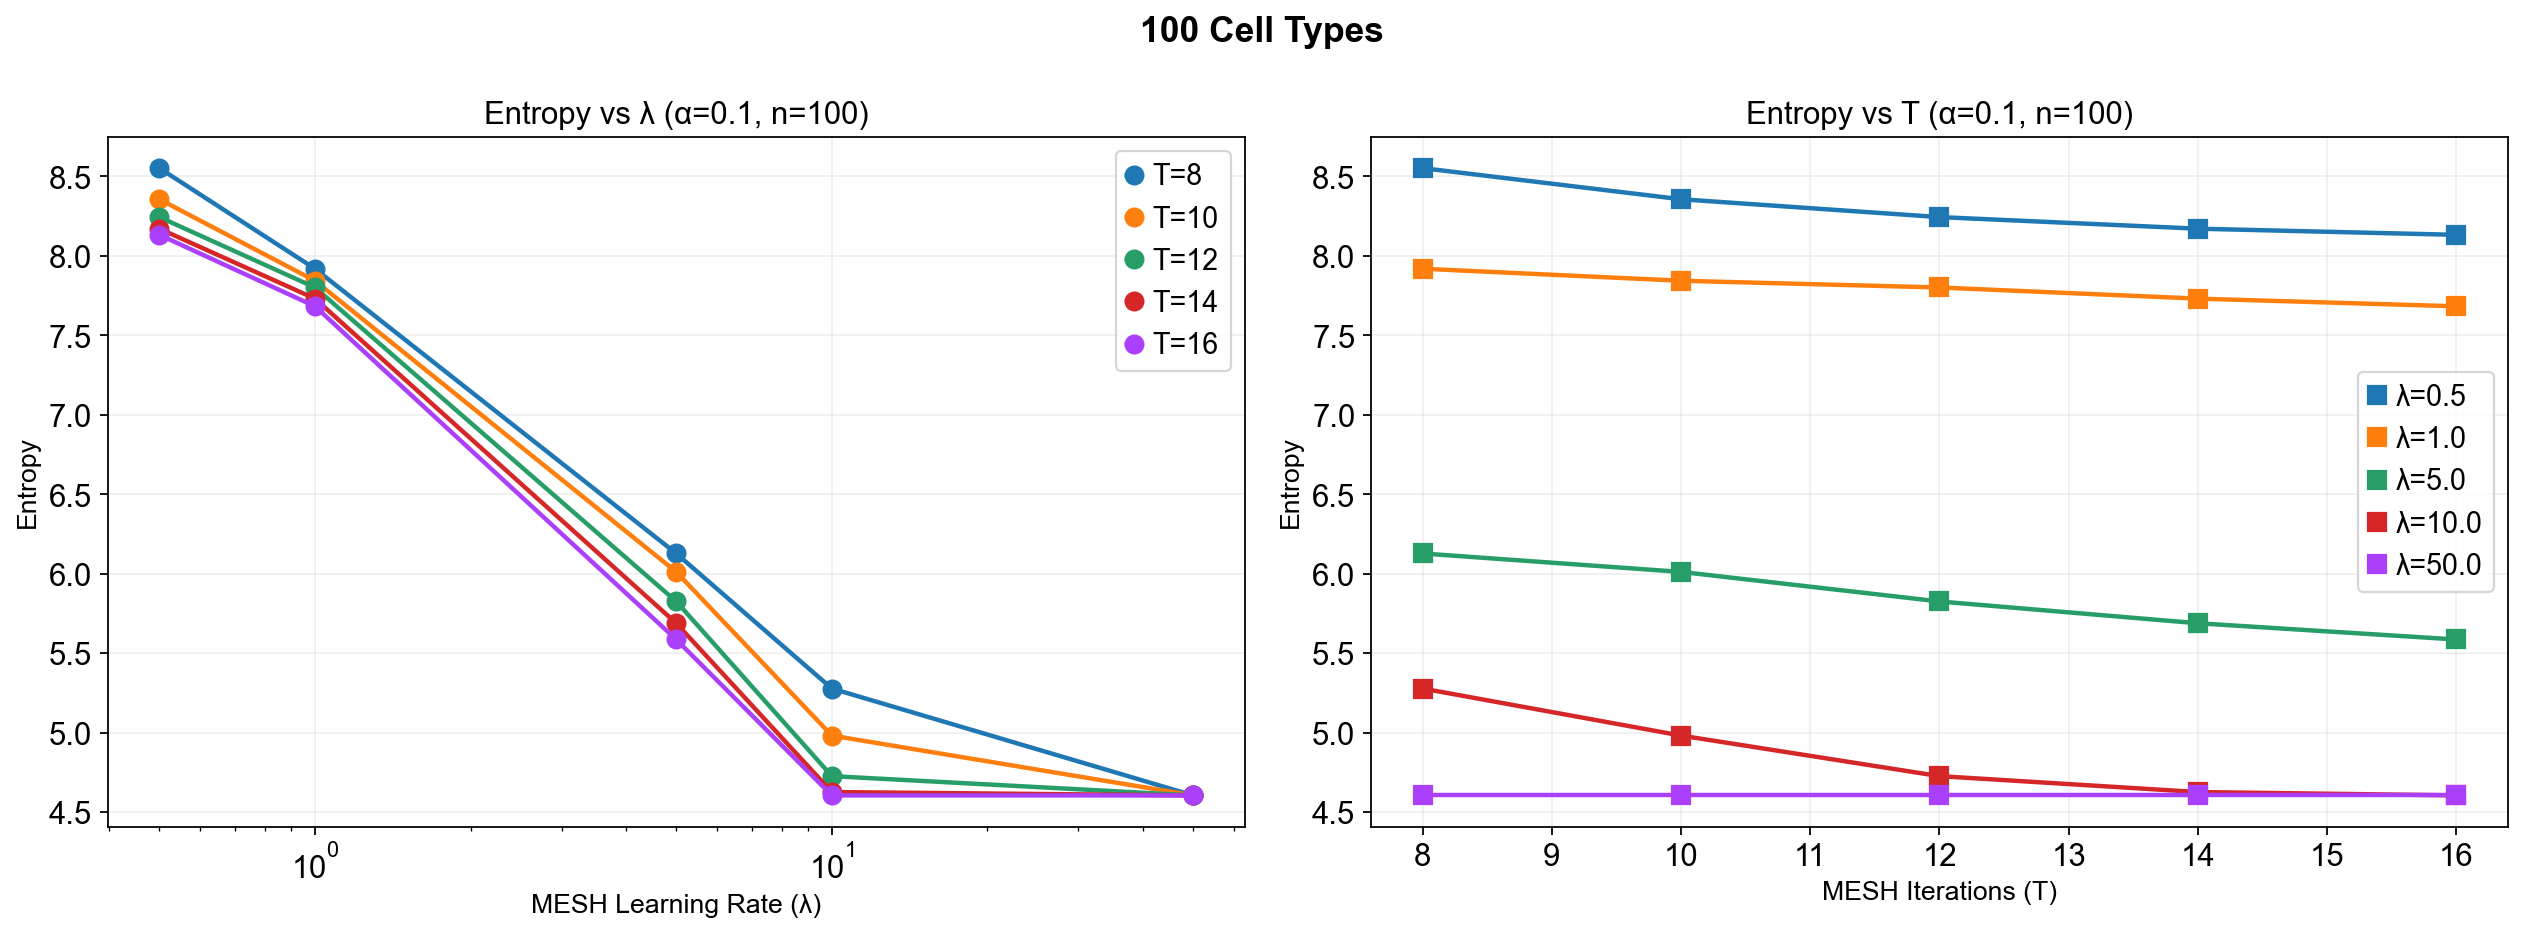

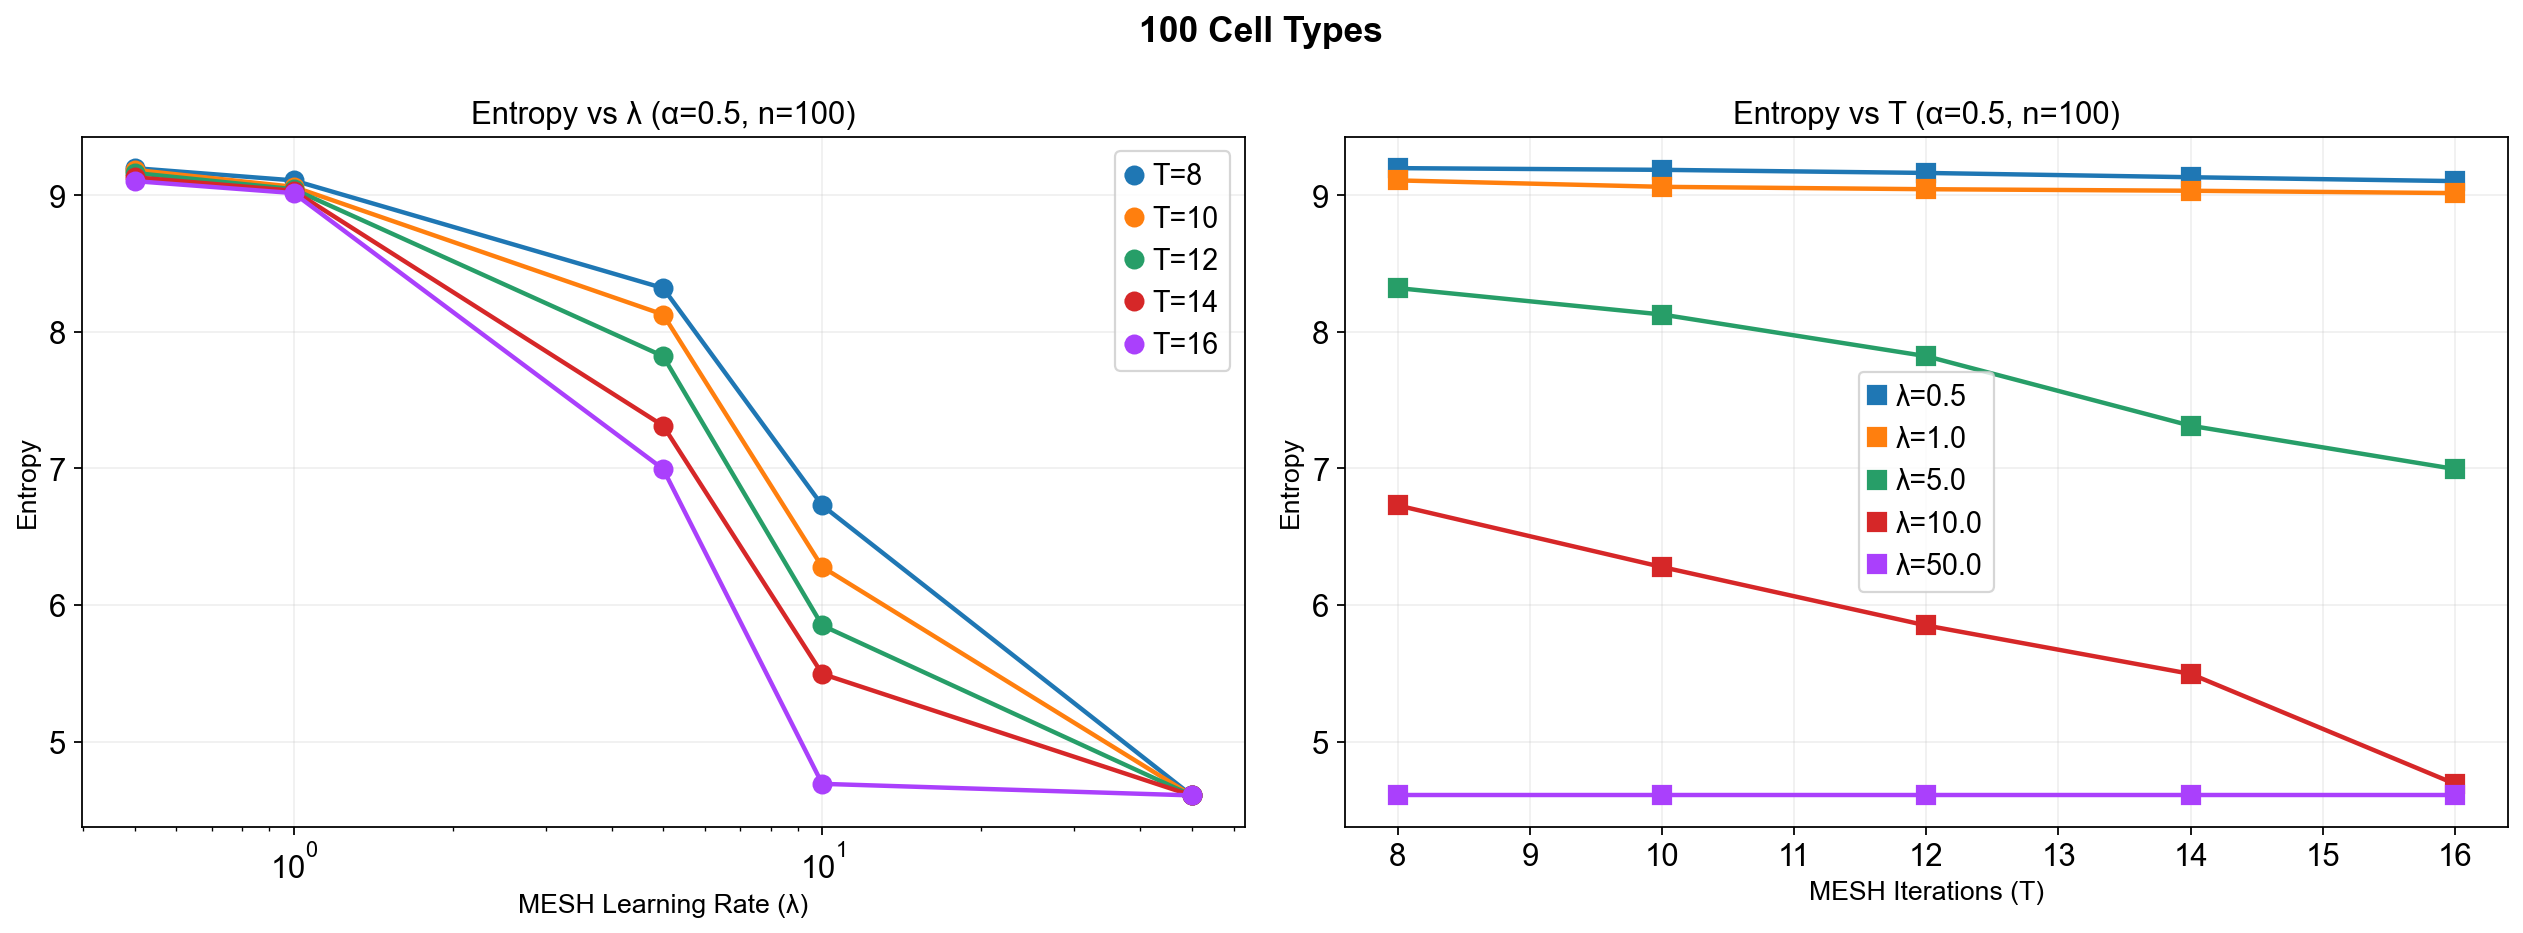

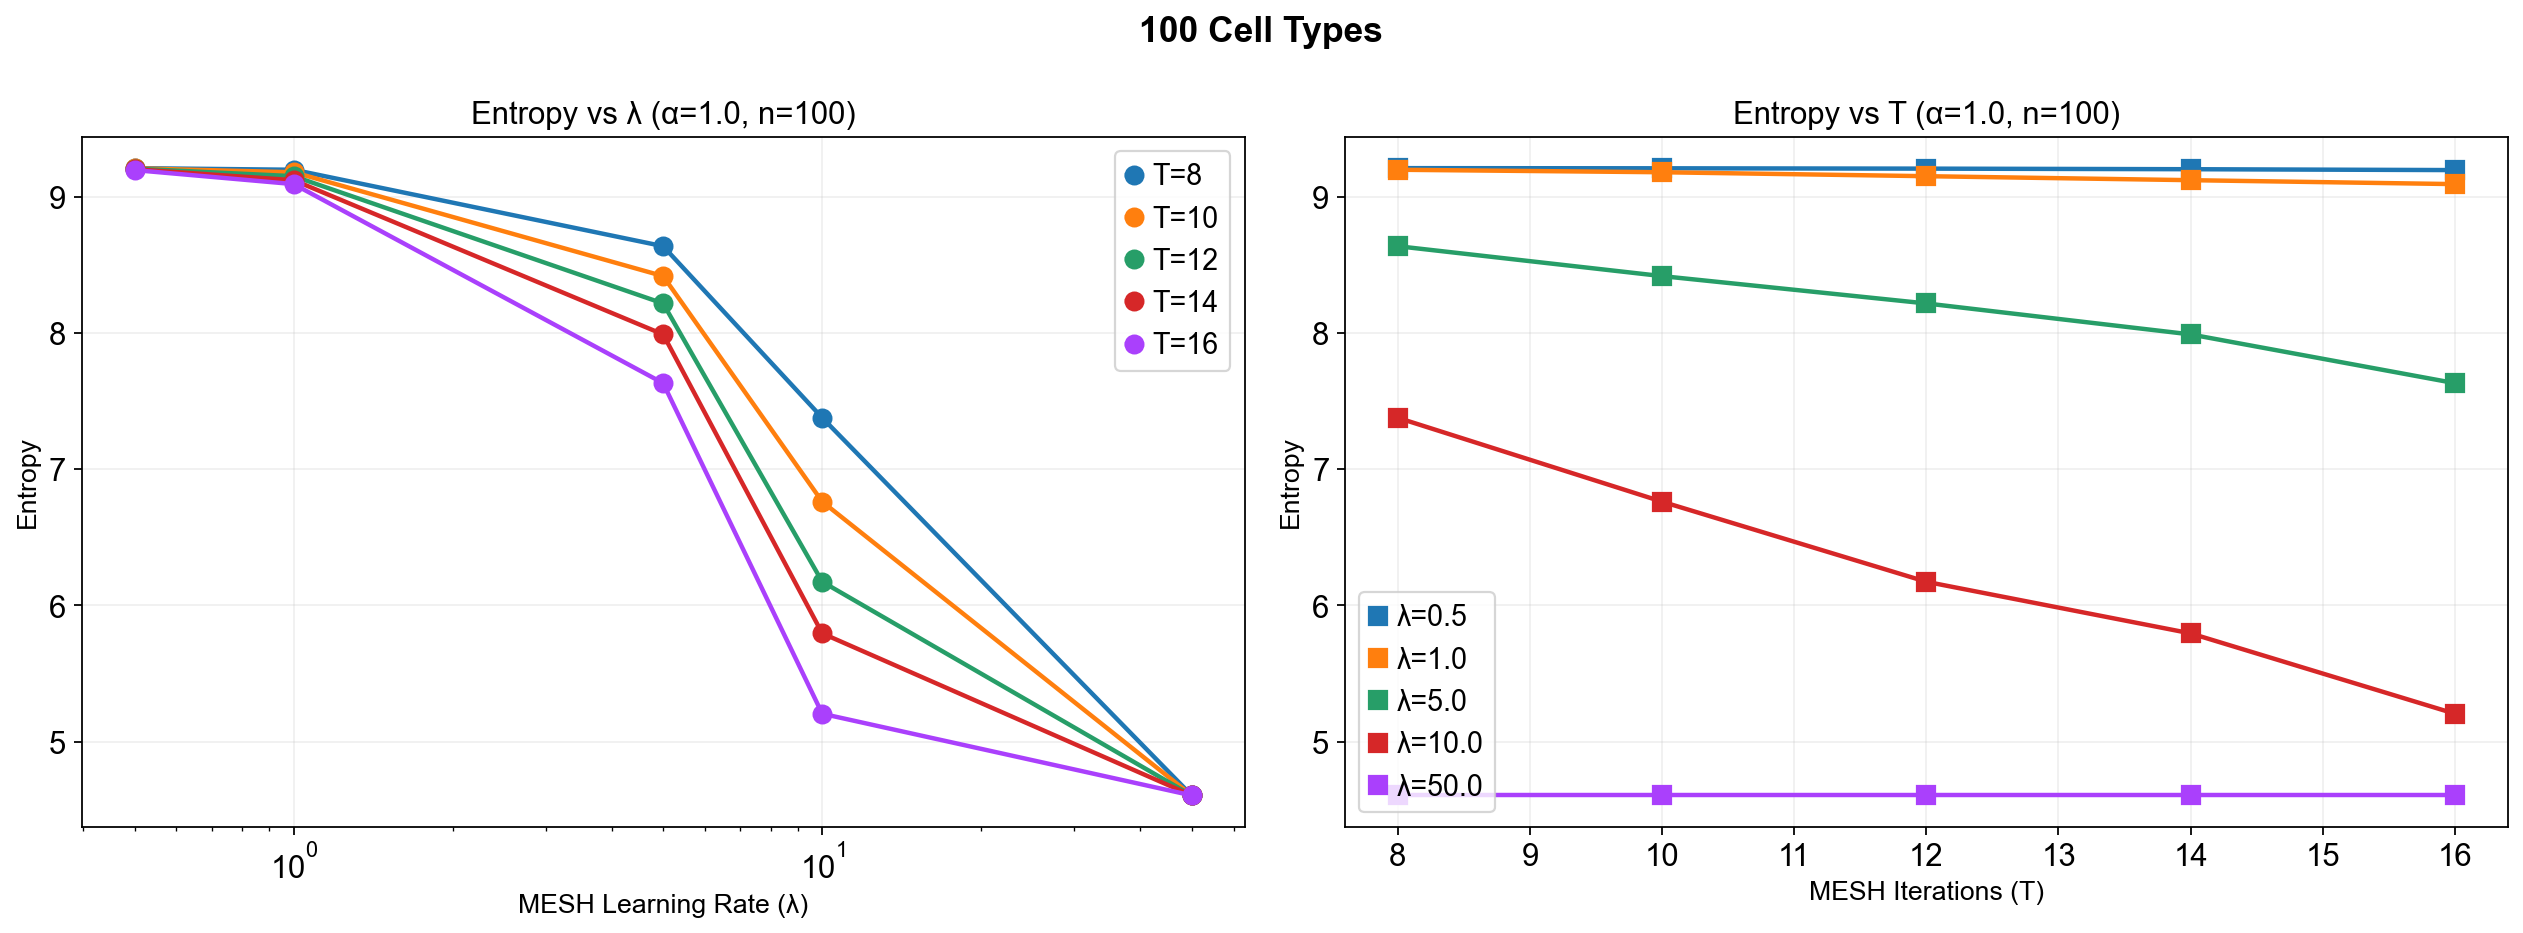

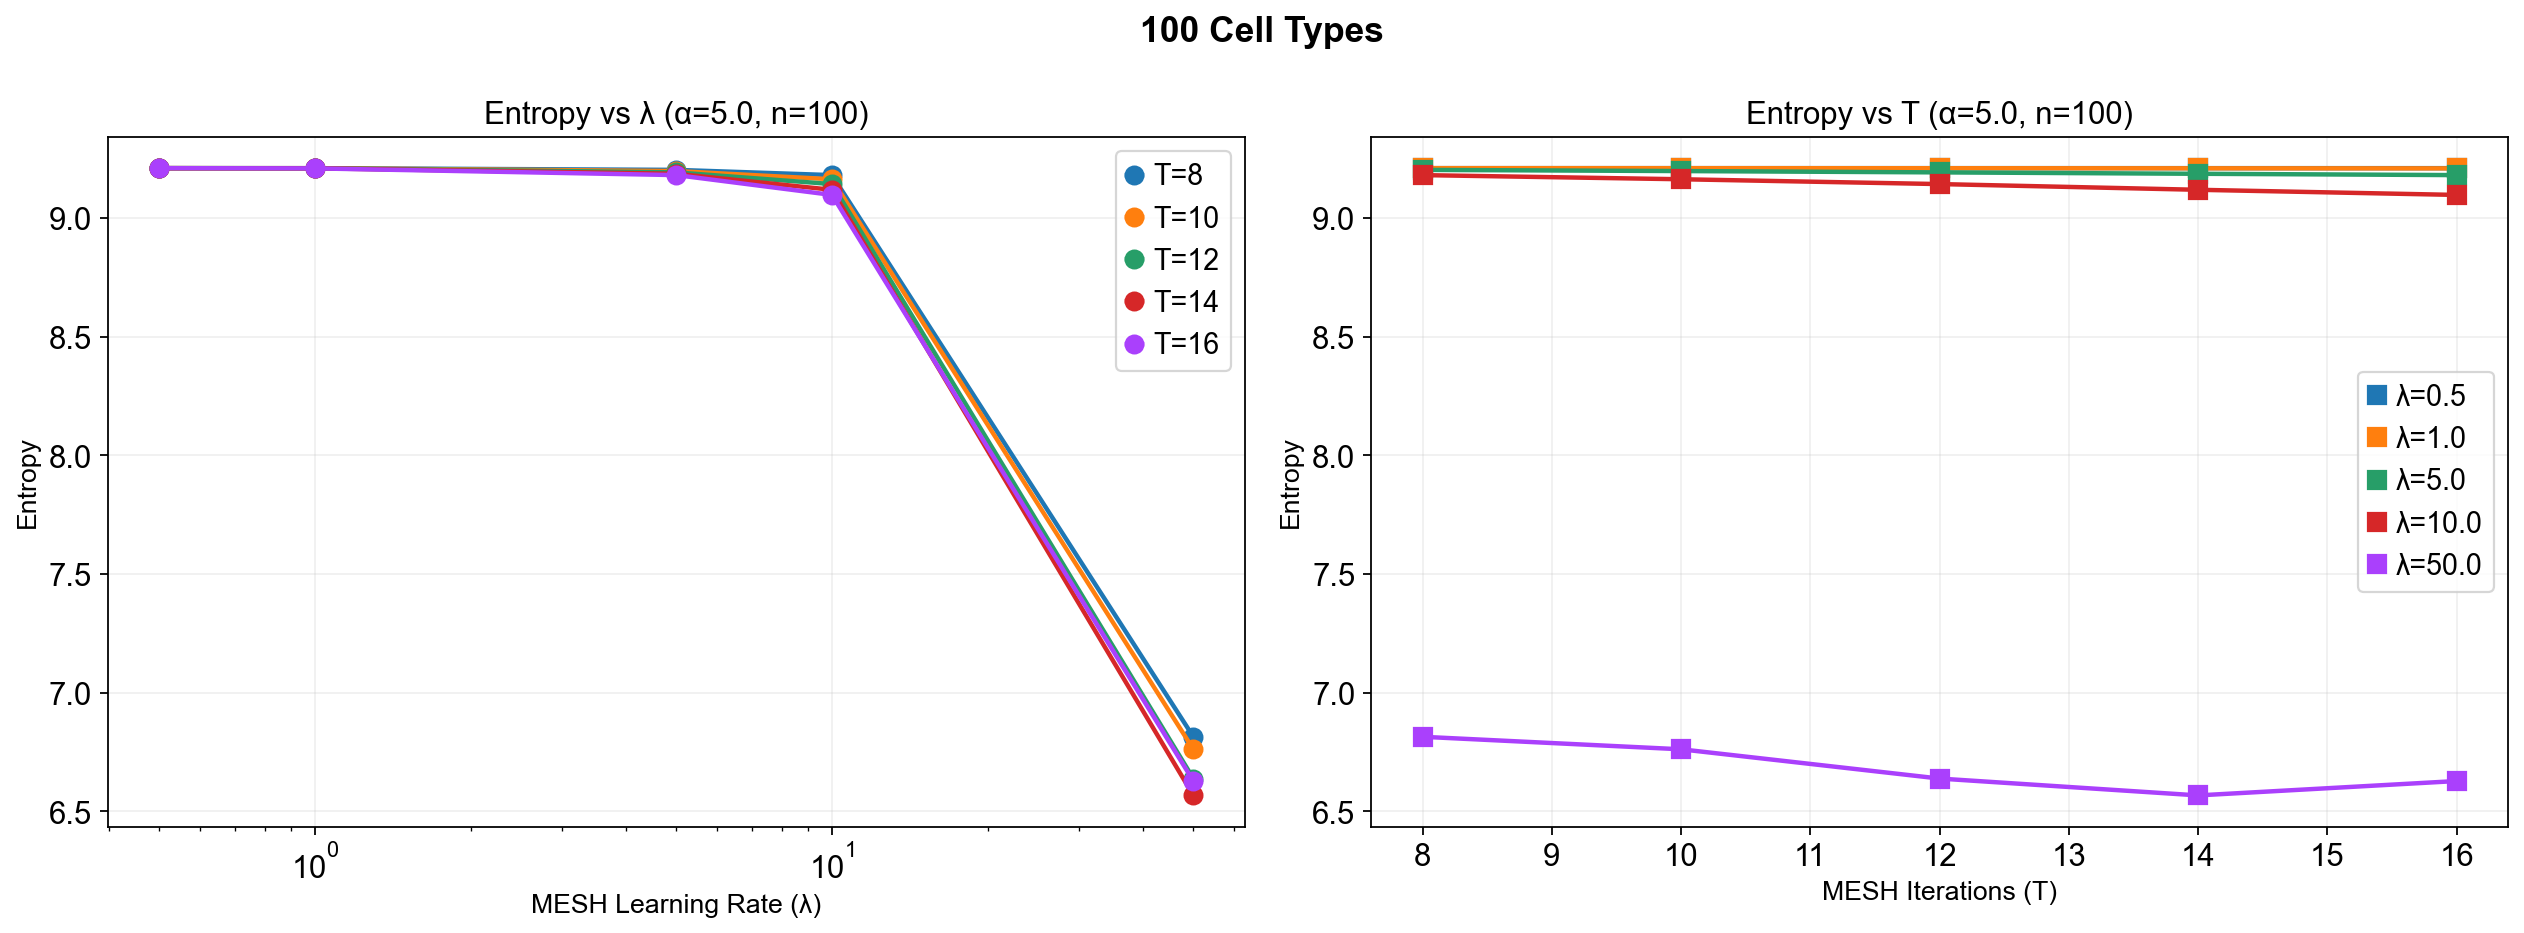

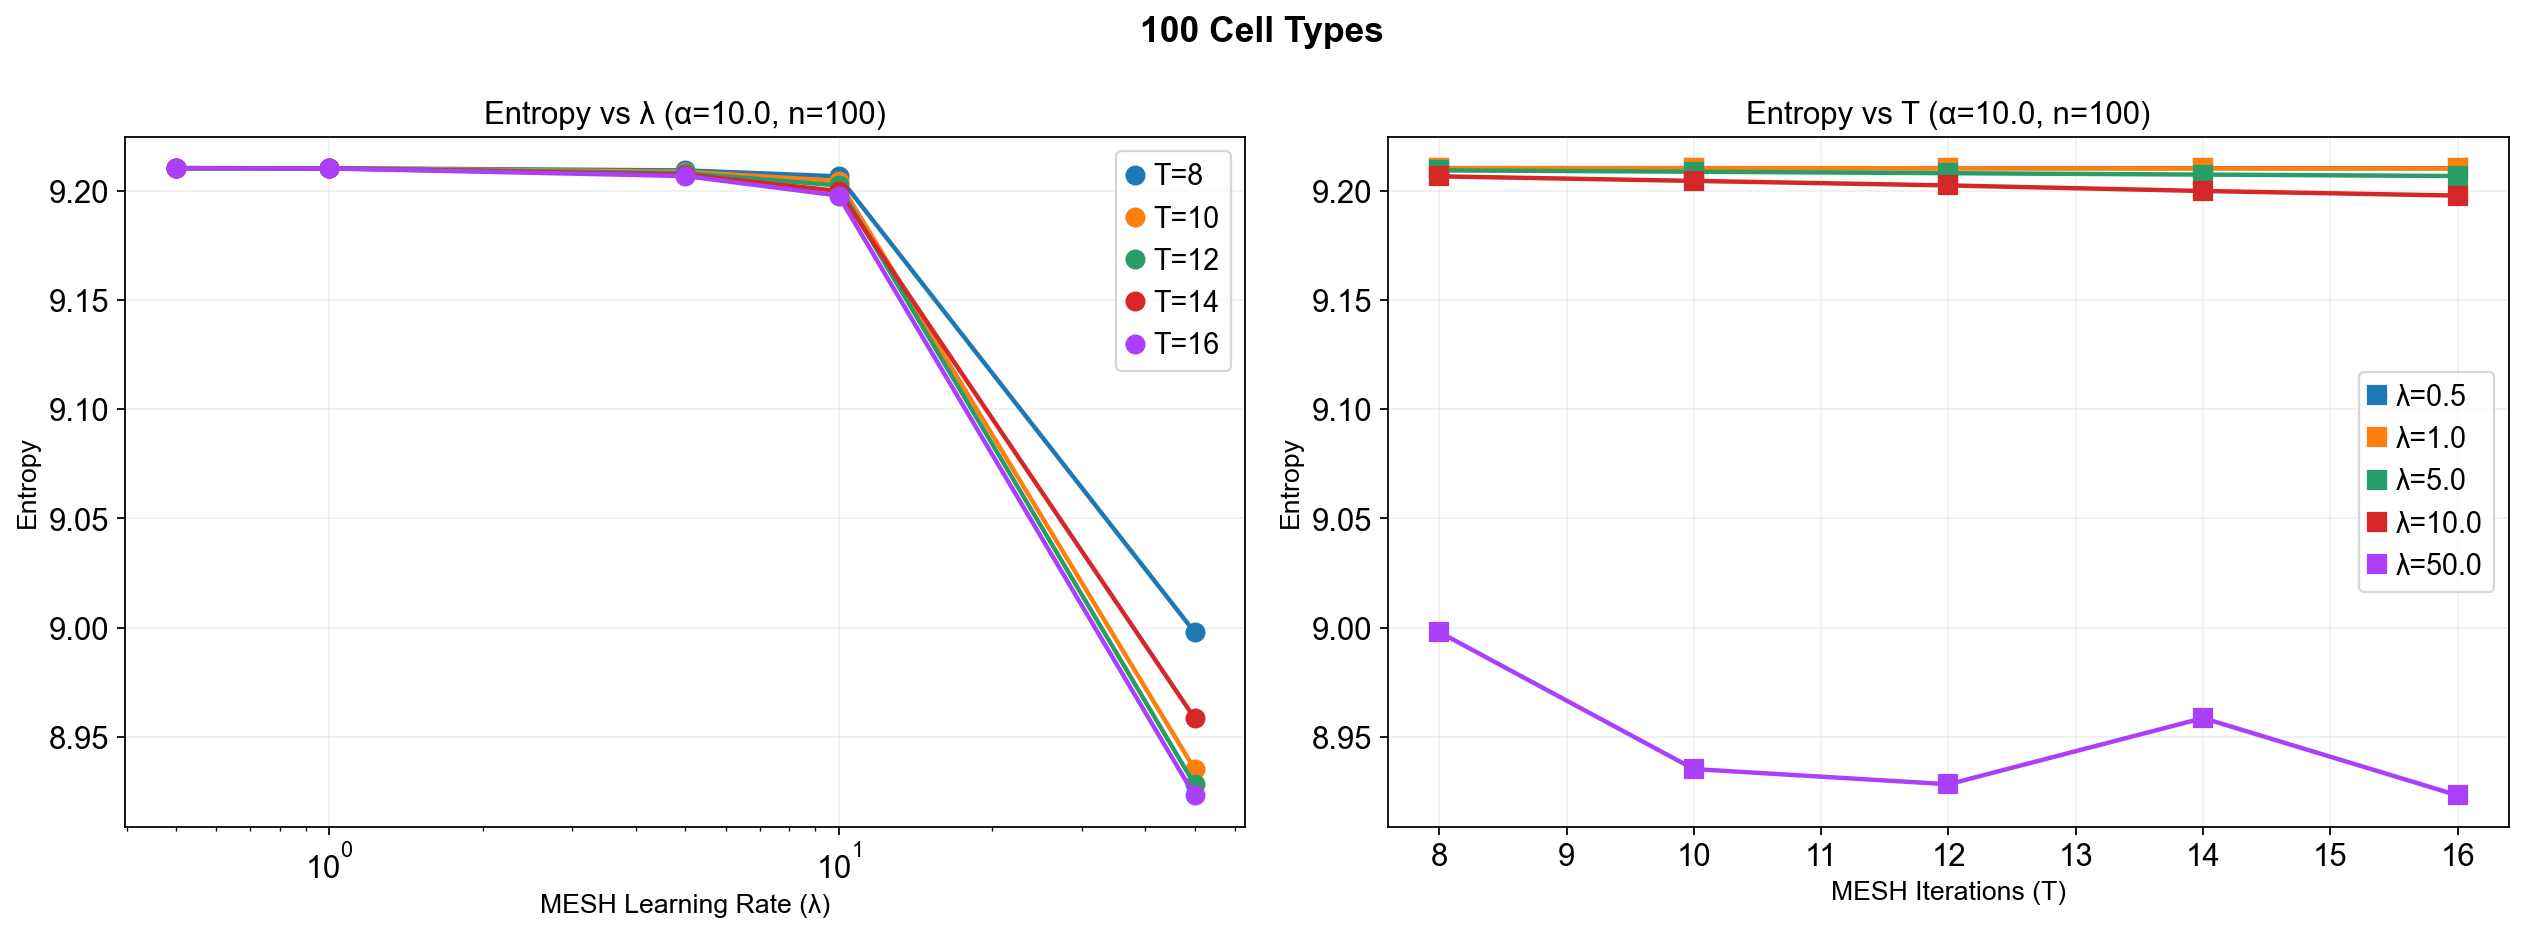


Parameter Selection for 200 Cell Types
Creating dataset...
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Using 200 genes

Running parameter sweep...
  Alpha values: [0.1, 0.5, 1.0, 5.0, 10.0]
  Lambda values: [0.5, 1.0, 5.0, 10.0, 50.0]
  T values: [8, 10, 12, 14, 16]
Starting parameter sweep with 125 combinations...
Progress: 12/125 (9.6%)
Progress: 24/125 (19.2%)
Progress: 36/125 (28.8%)
Progress: 48/125 (38.4%)
Progress: 60/125 (48.0%)
Progress: 72/125 (57.6%)
Progress: 84/125 (67.2%)
Progress: 96/125 (76.8%)
Progress: 108/125 (86.4%)
Progress: 120/125 (96.0%)
Parameter sweep completed in 7.9 seconds!

Generating elbow curves for manual selection...


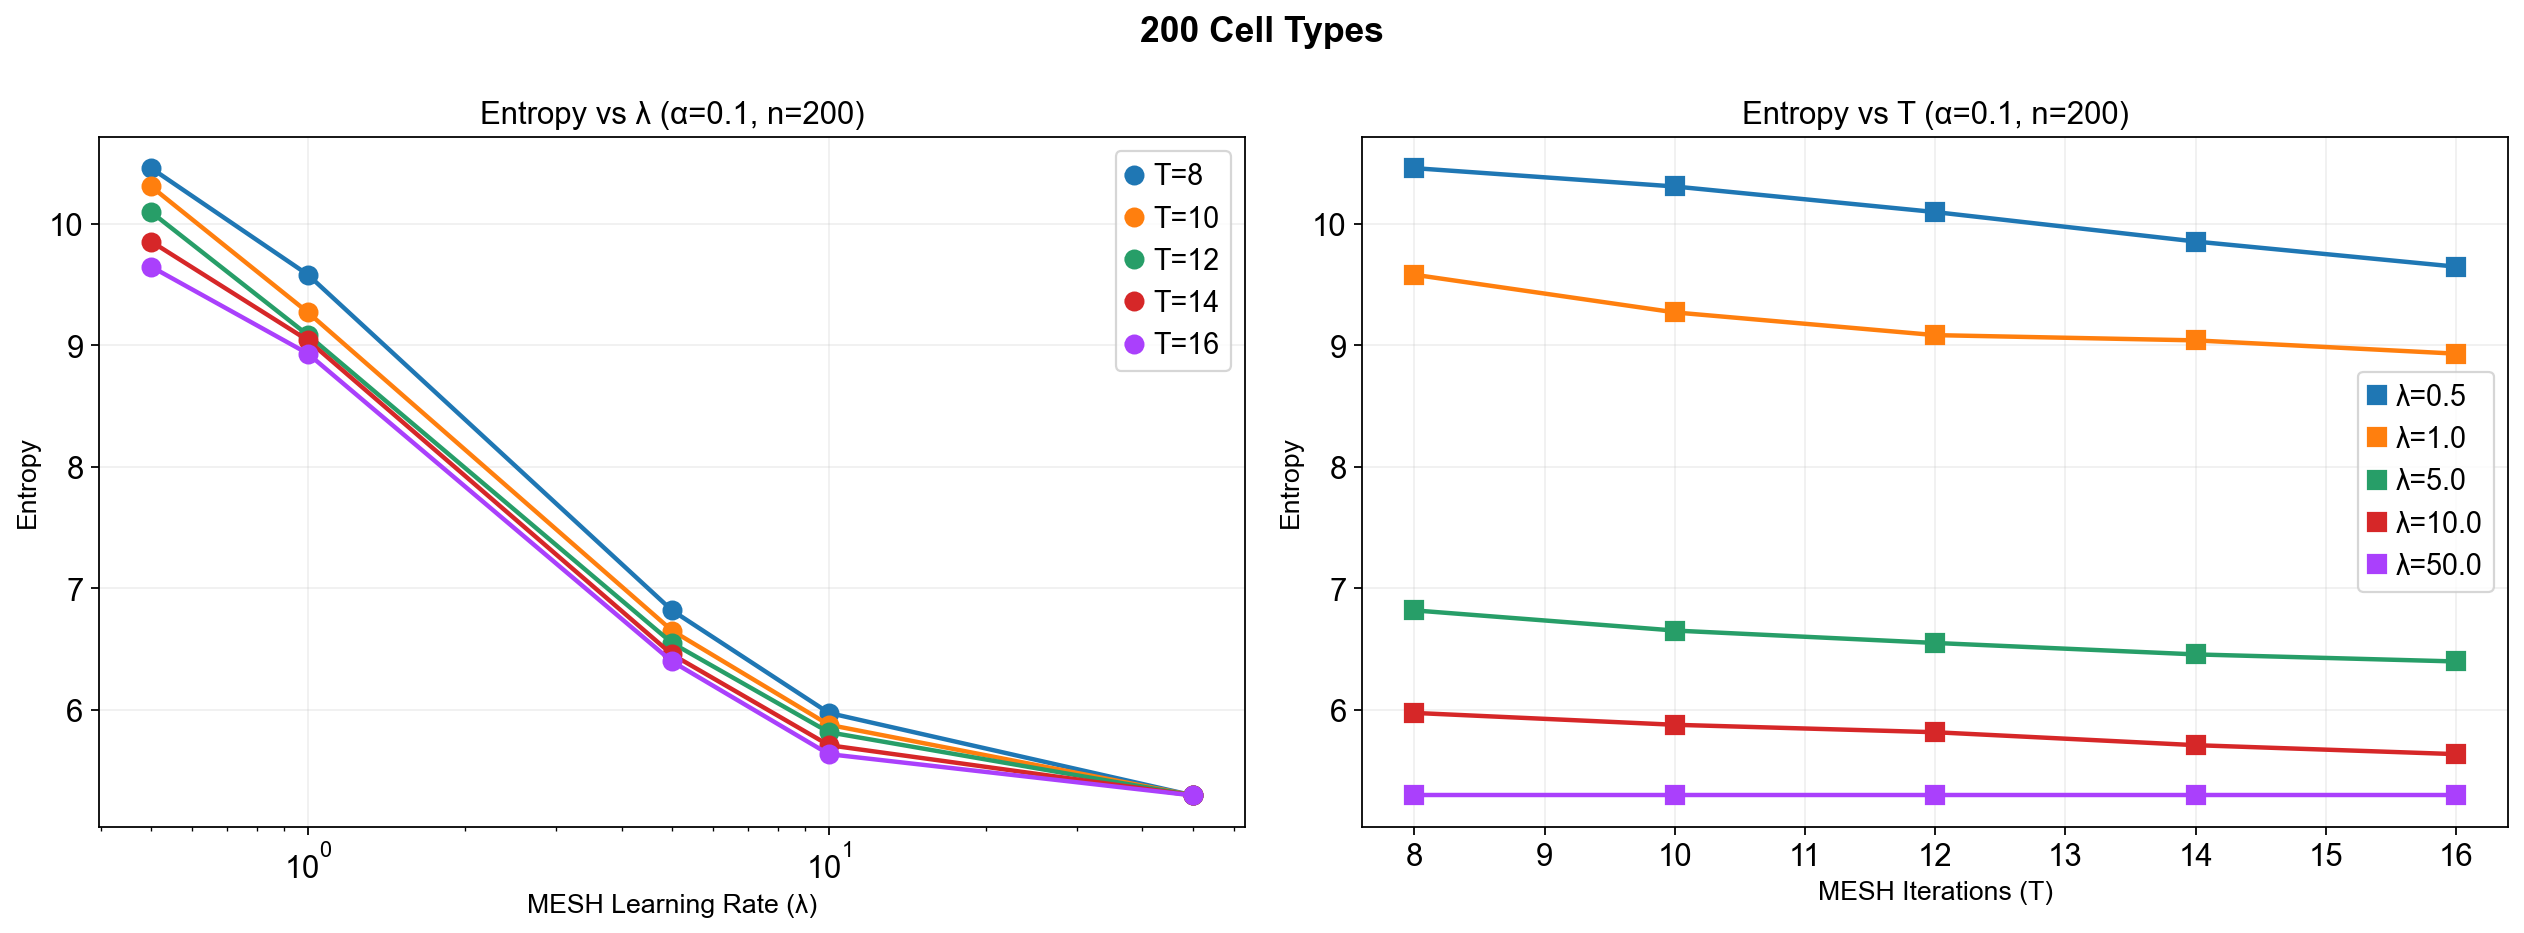

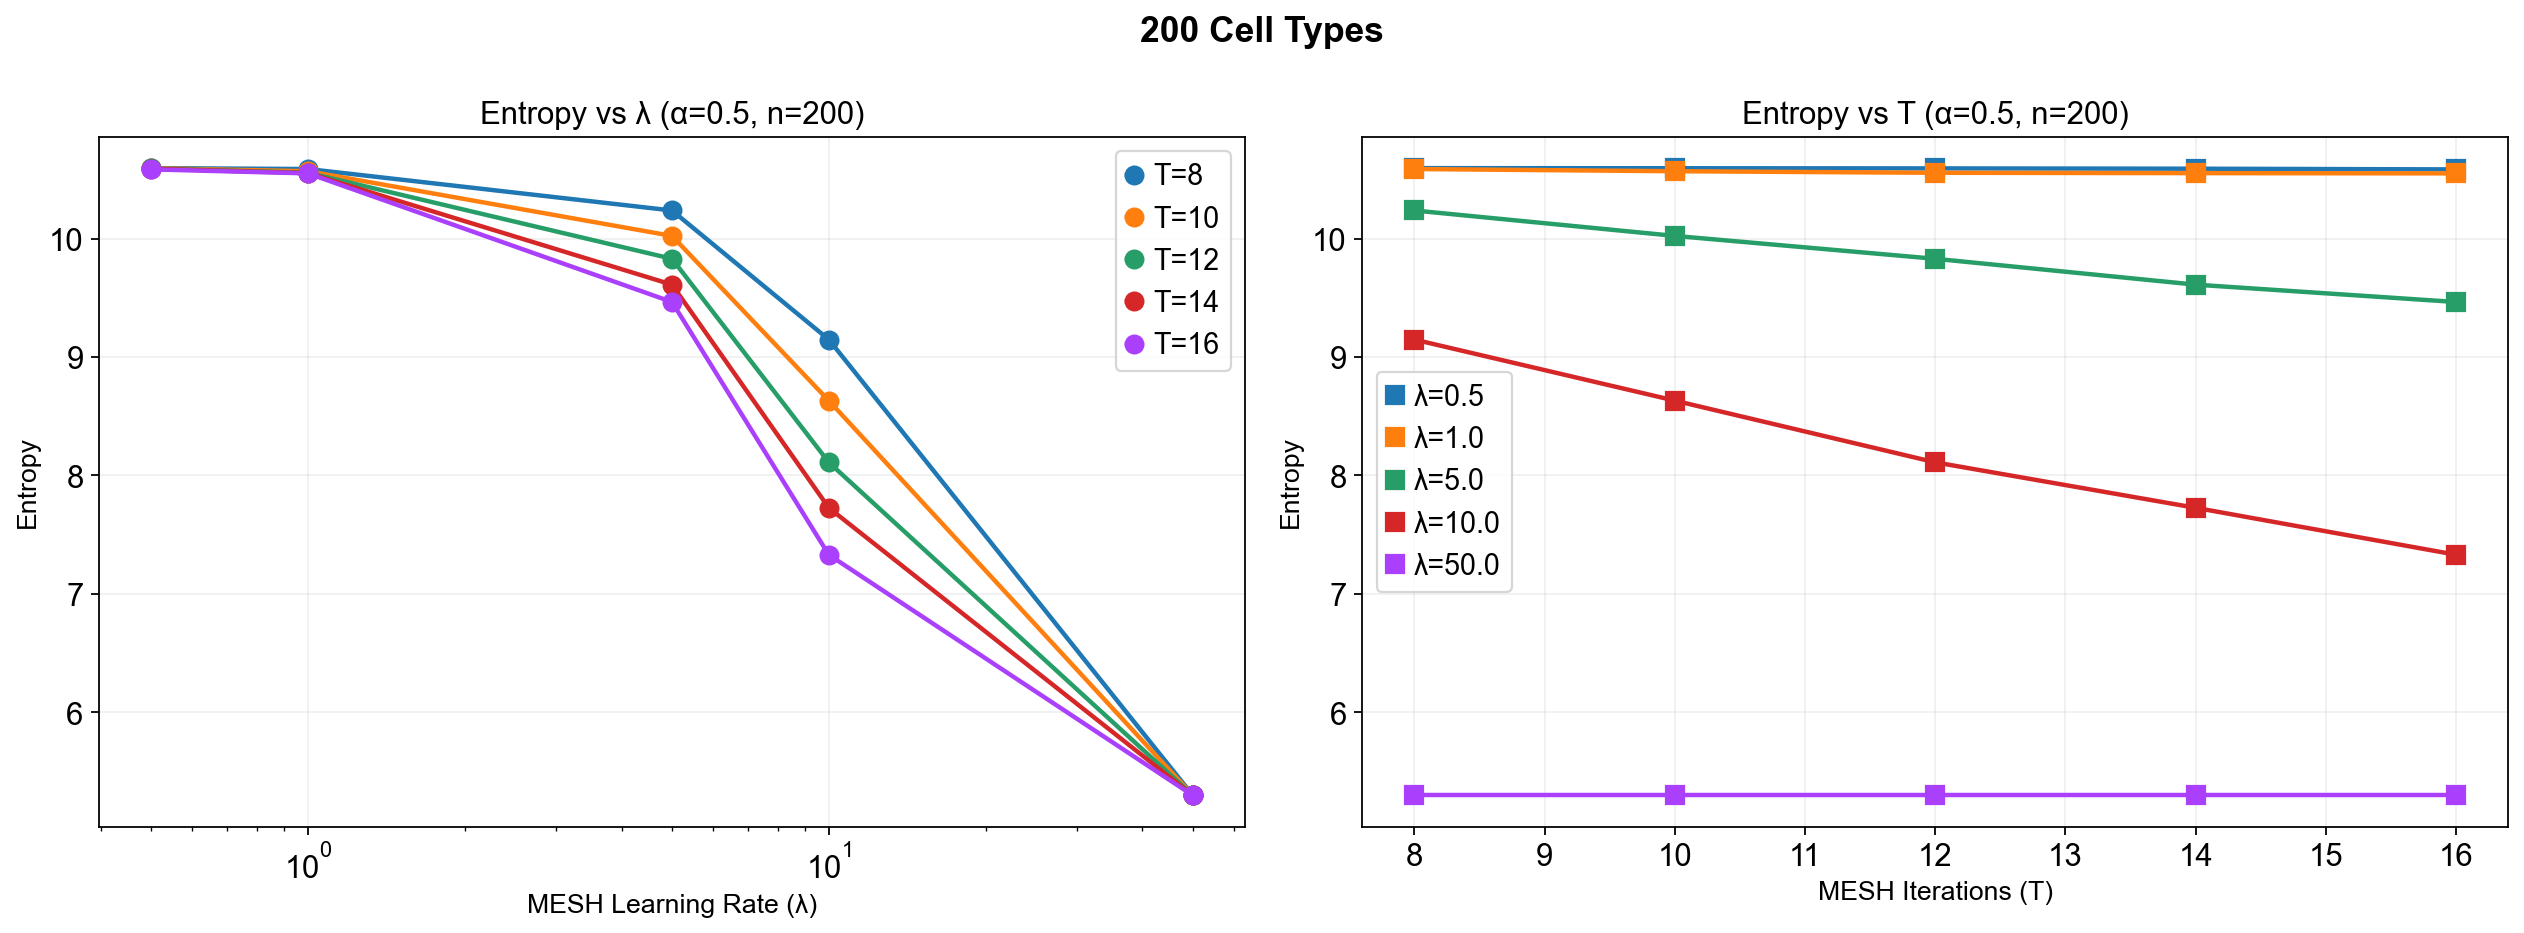

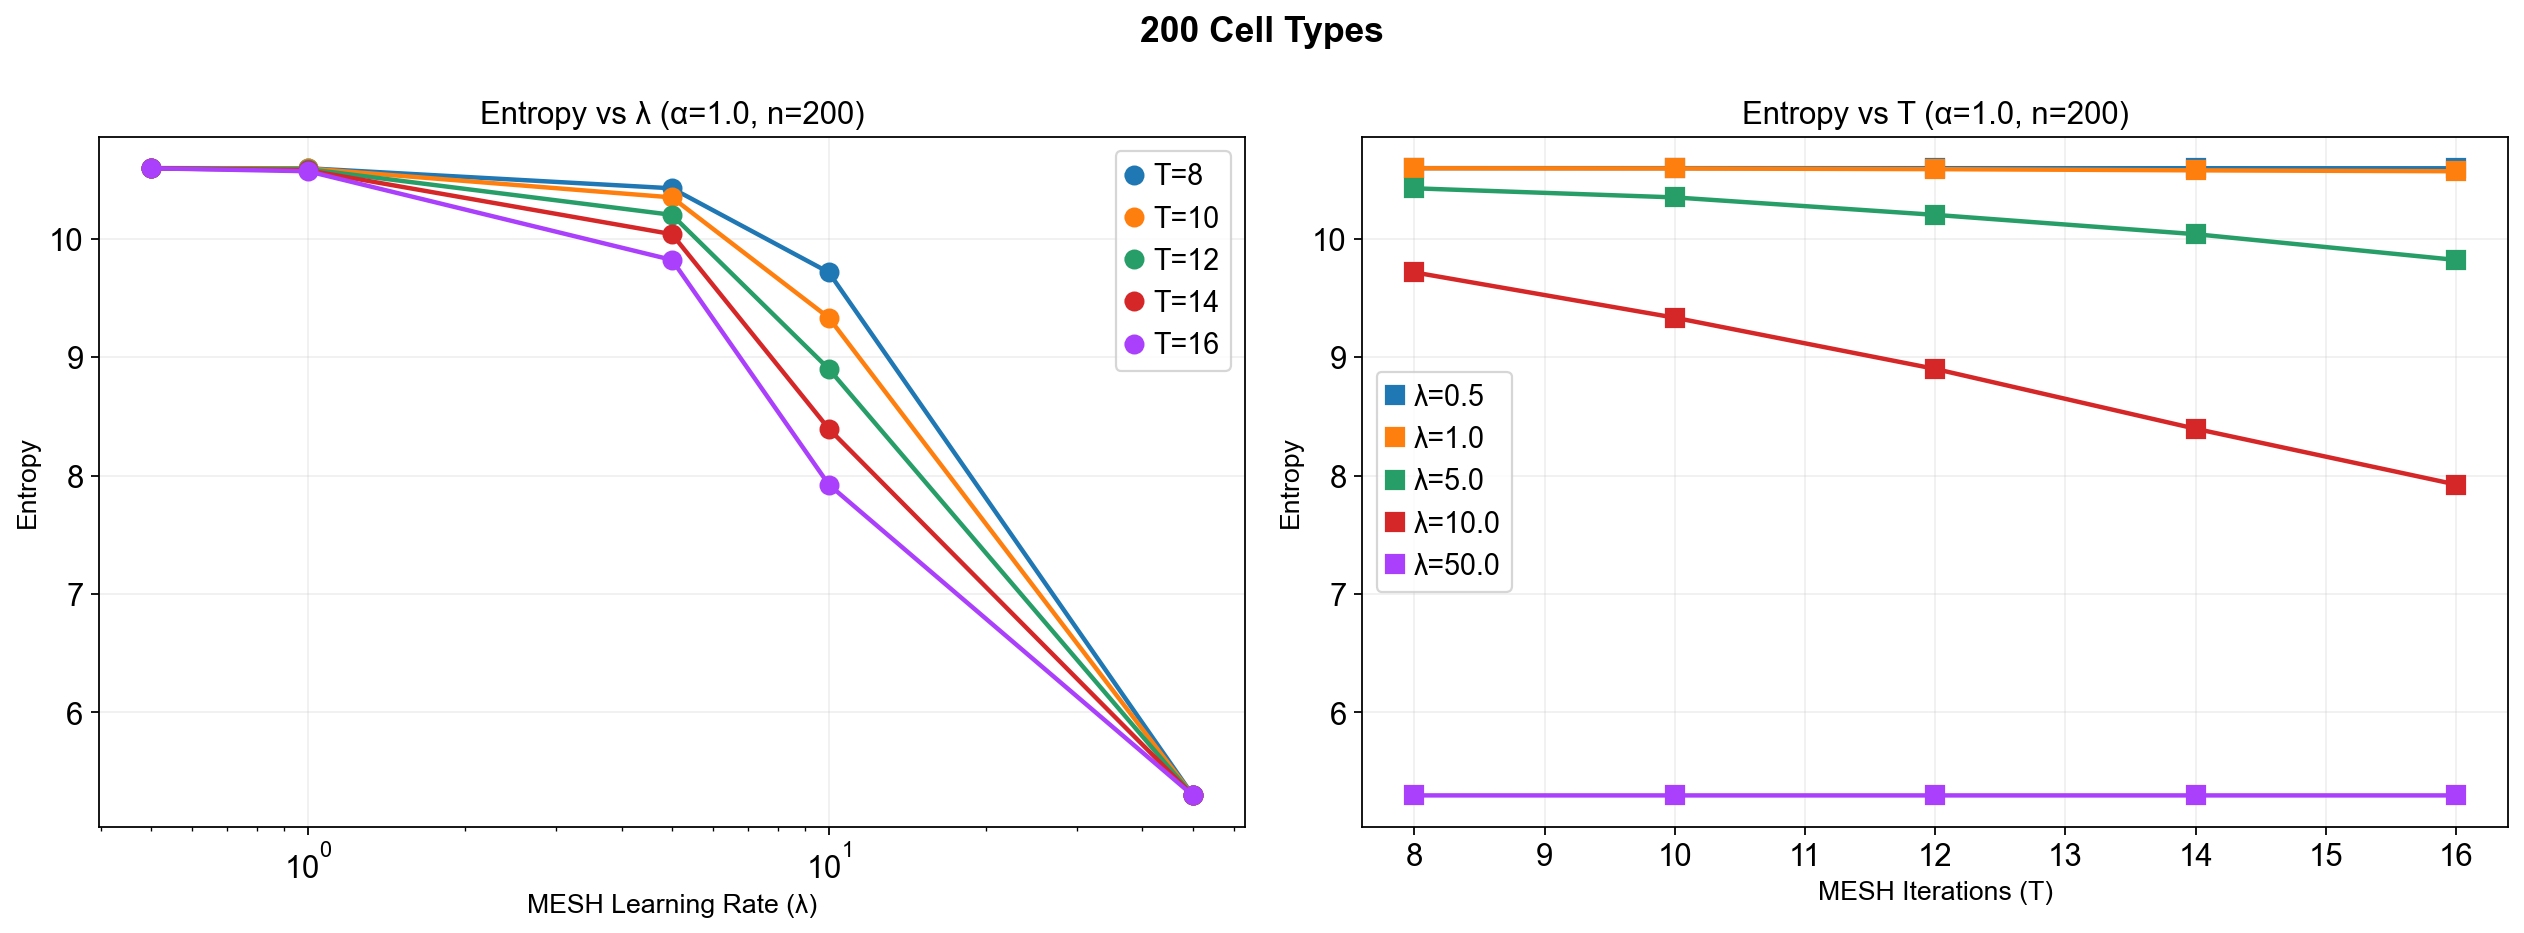

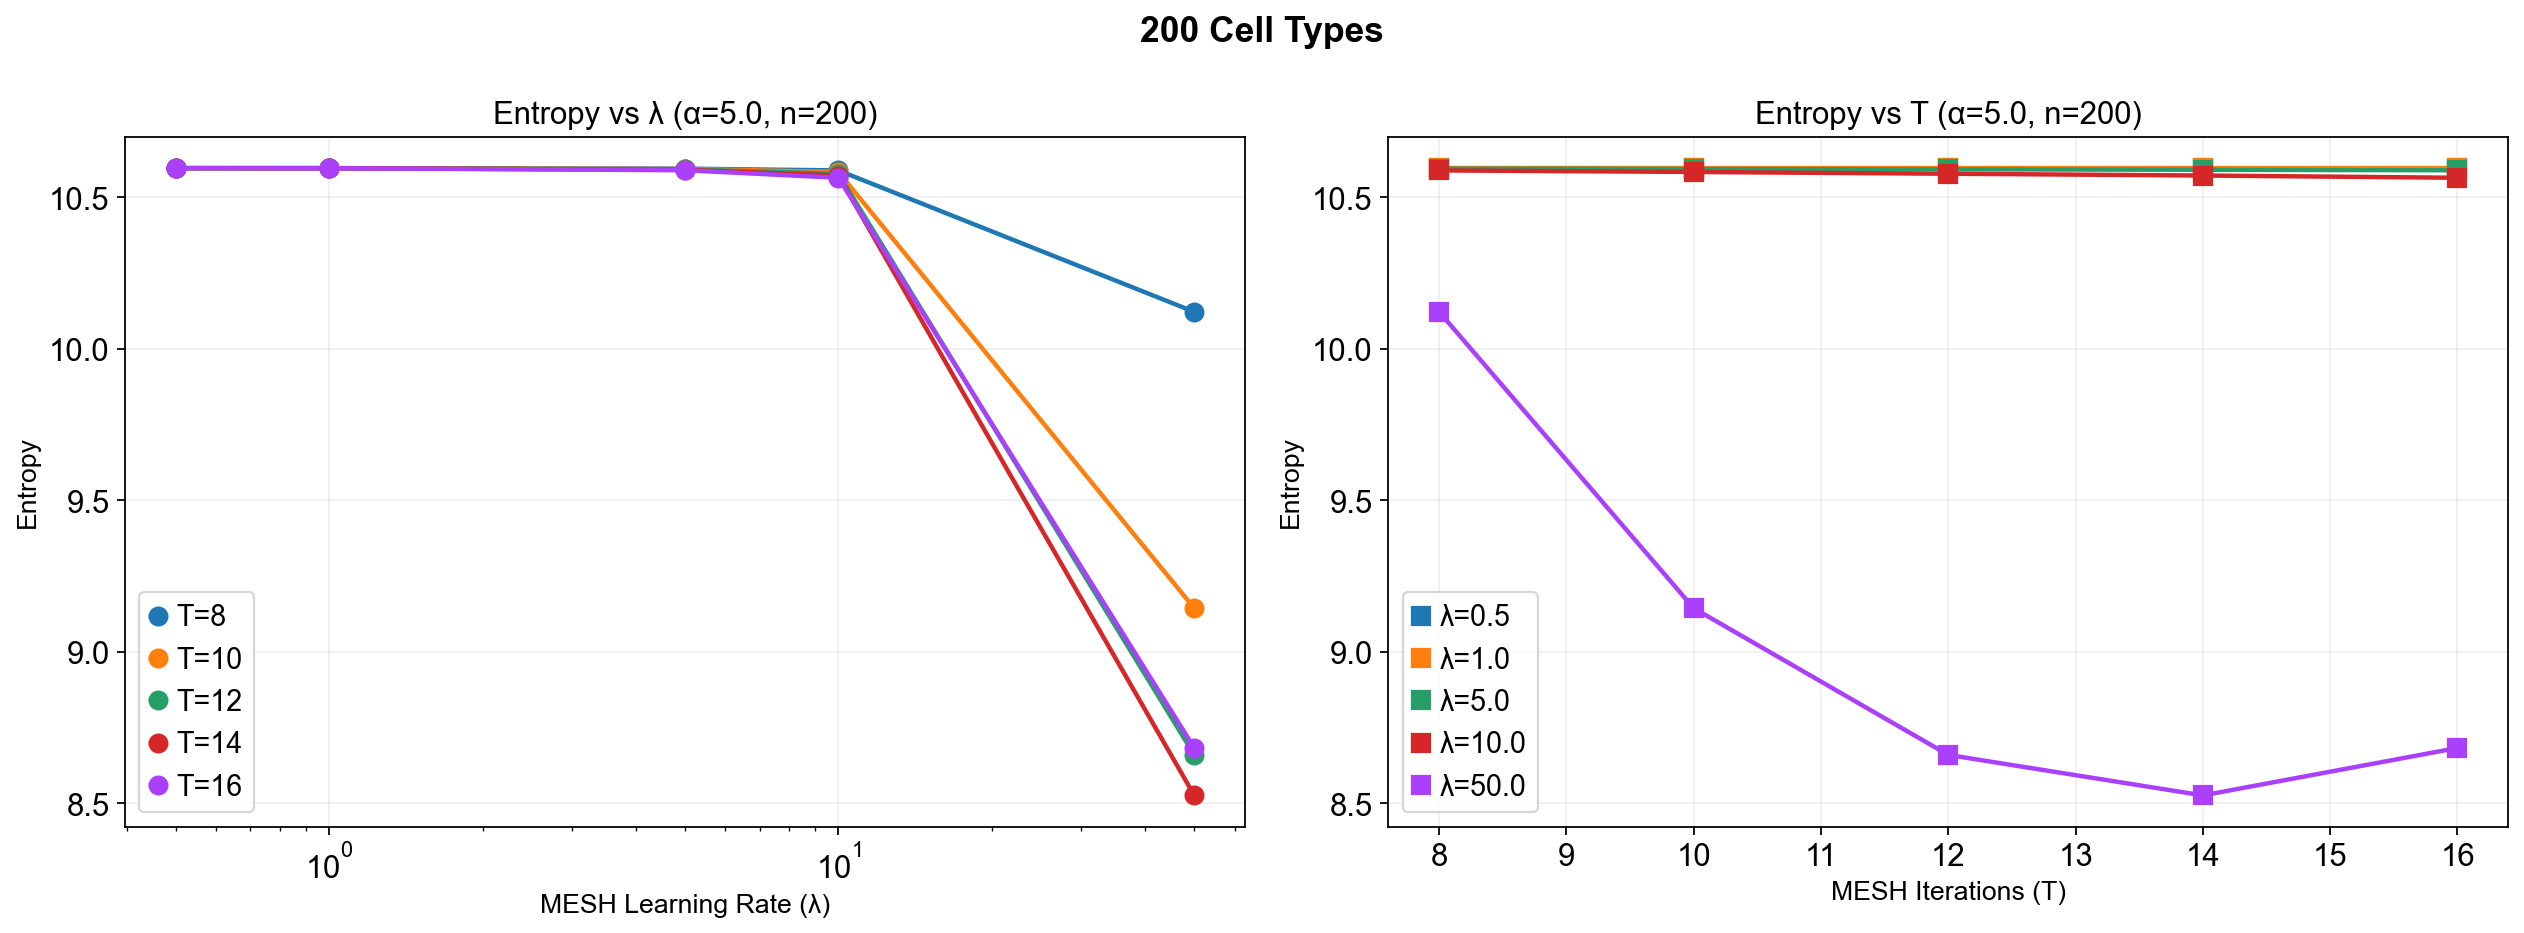

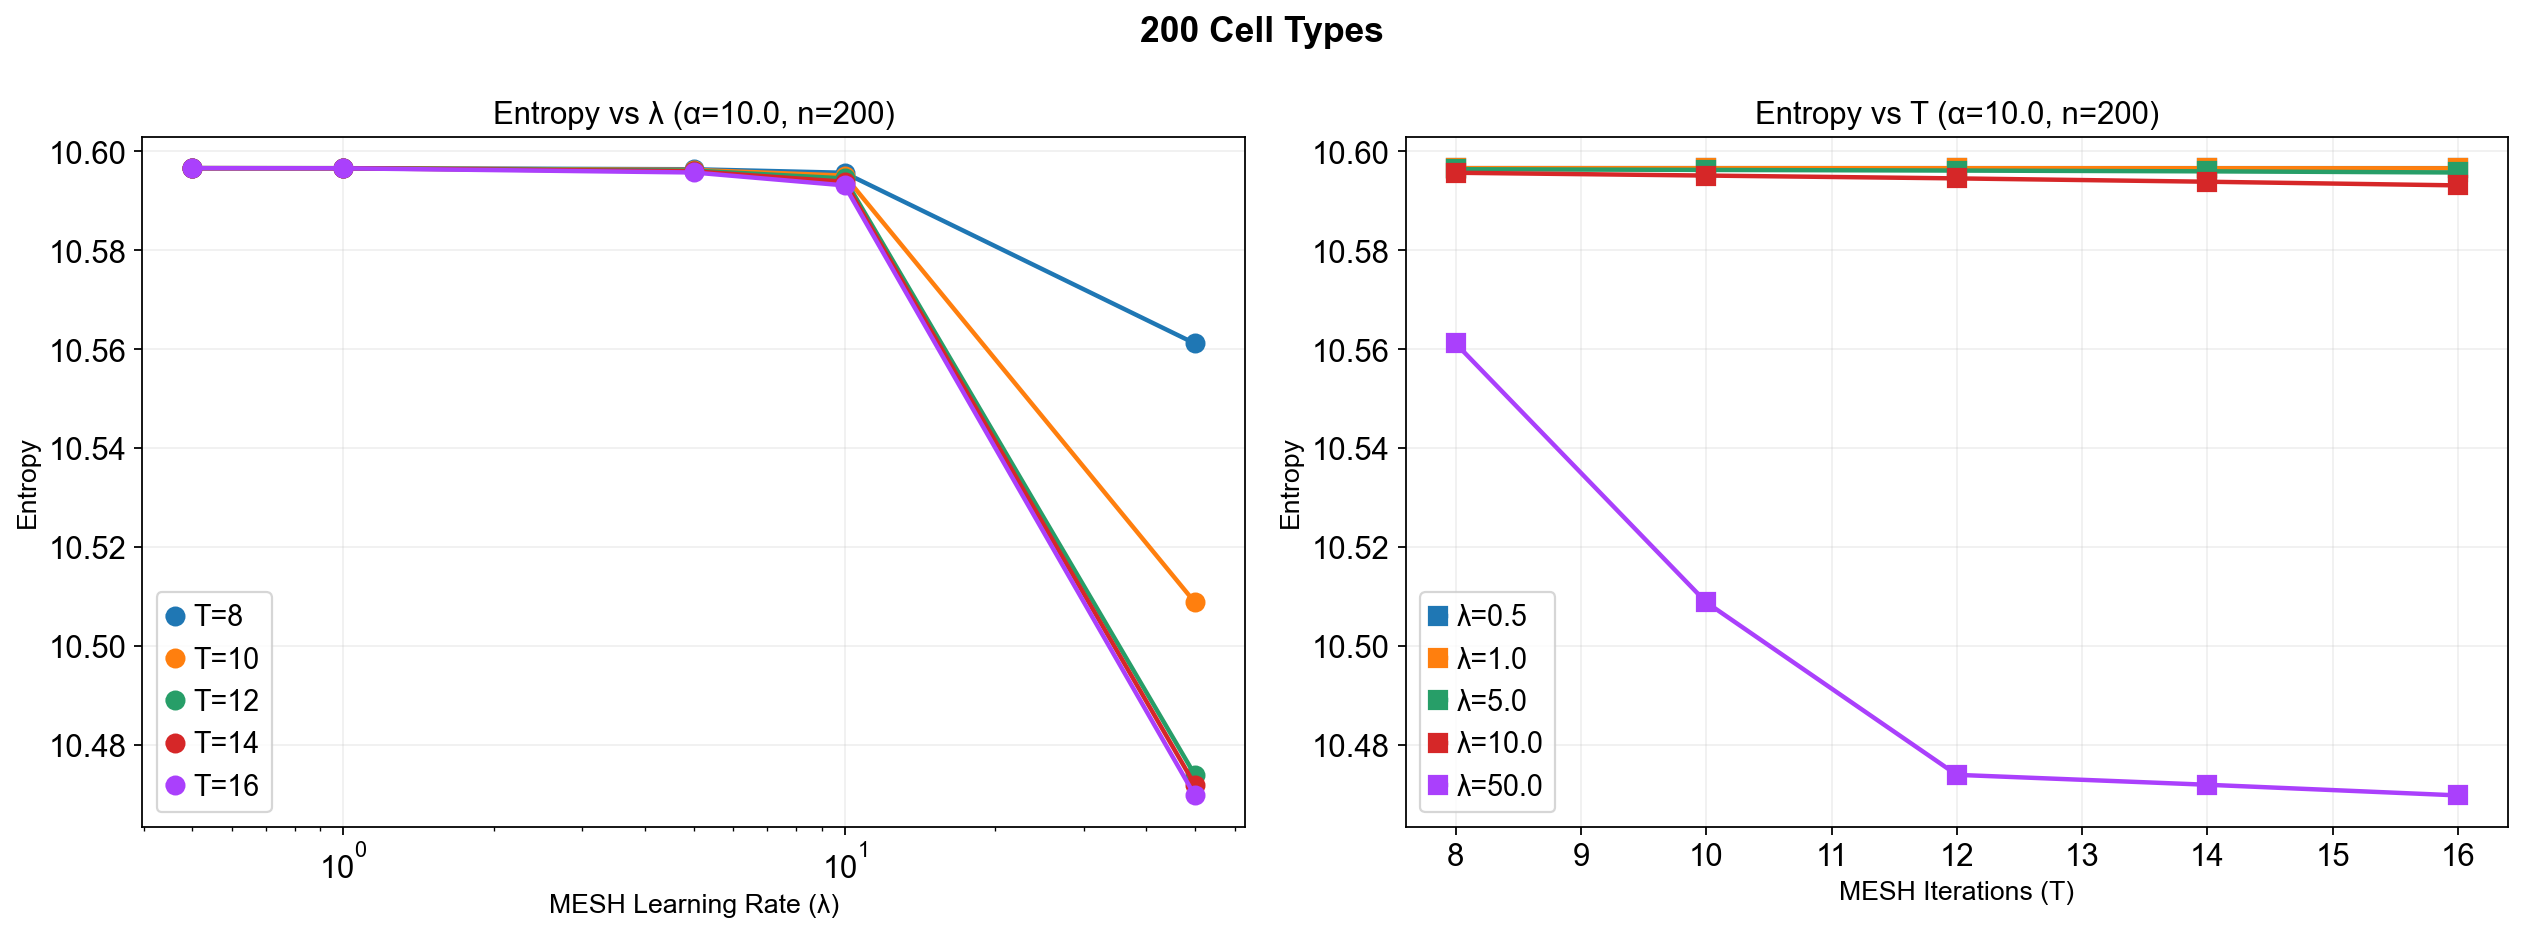


Parameter Selection for 500 Cell Types
Creating dataset...
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Using 200 genes

Running parameter sweep...
  Alpha values: [0.1, 0.5, 1.0, 5.0, 10.0]
  Lambda values: [0.5, 1.0, 5.0, 10.0, 50.0]
  T values: [8, 10, 12, 14, 16]
Starting parameter sweep with 125 combinations...
Progress: 12/125 (9.6%)
Progress: 24/125 (19.2%)
Progress: 36/125 (28.8%)
Progress: 48/125 (38.4%)
Progress: 60/125 (48.0%)
Progress: 72/125 (57.6%)
Progress: 84/125 (67.2%)
Progress: 96/125 (76.8%)
Progress: 108/125 (86.4%)
Progress: 120/125 (96.0%)
Parameter sweep completed in 23.0 seconds!

Generating elbow curves for manual selection...


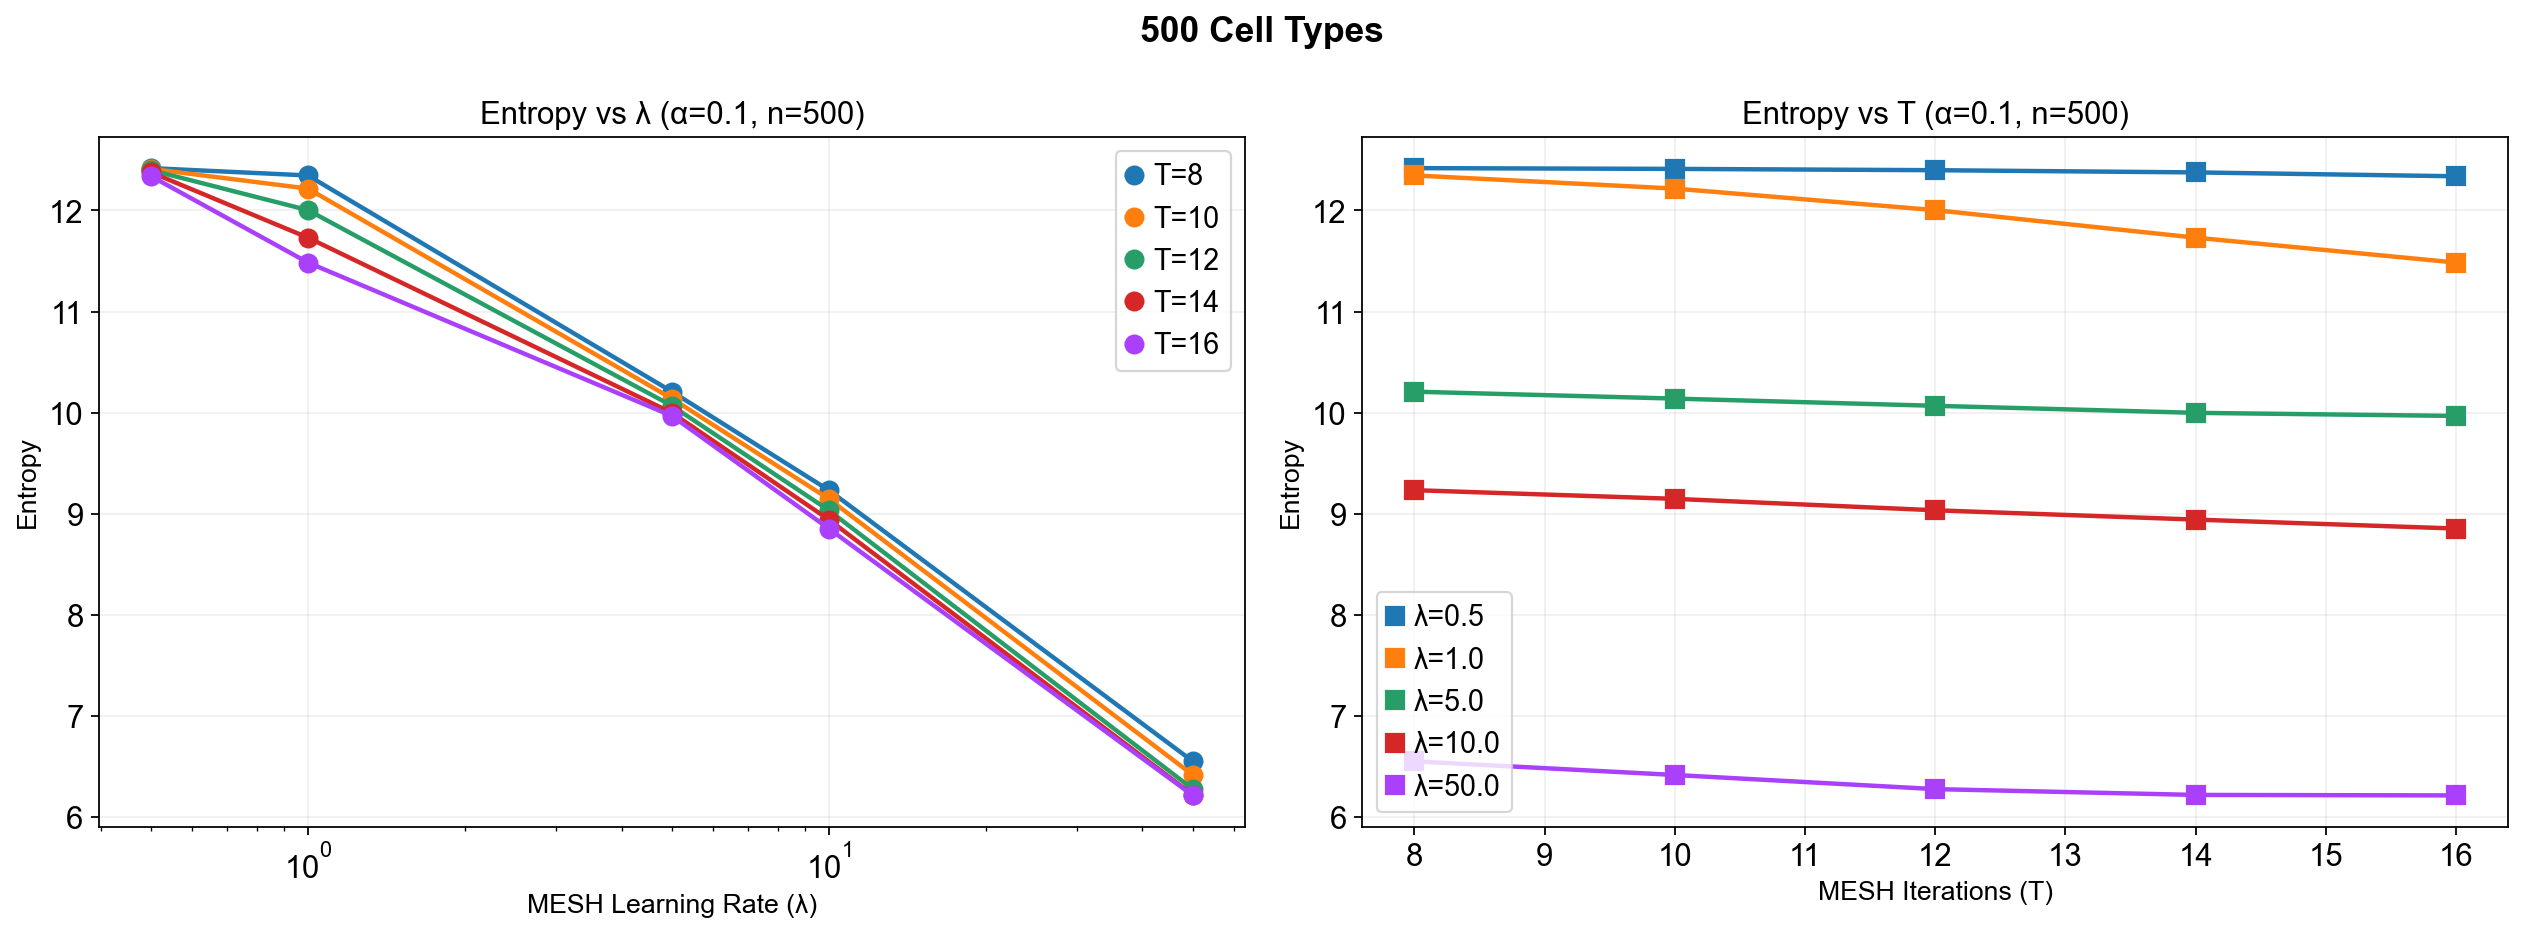

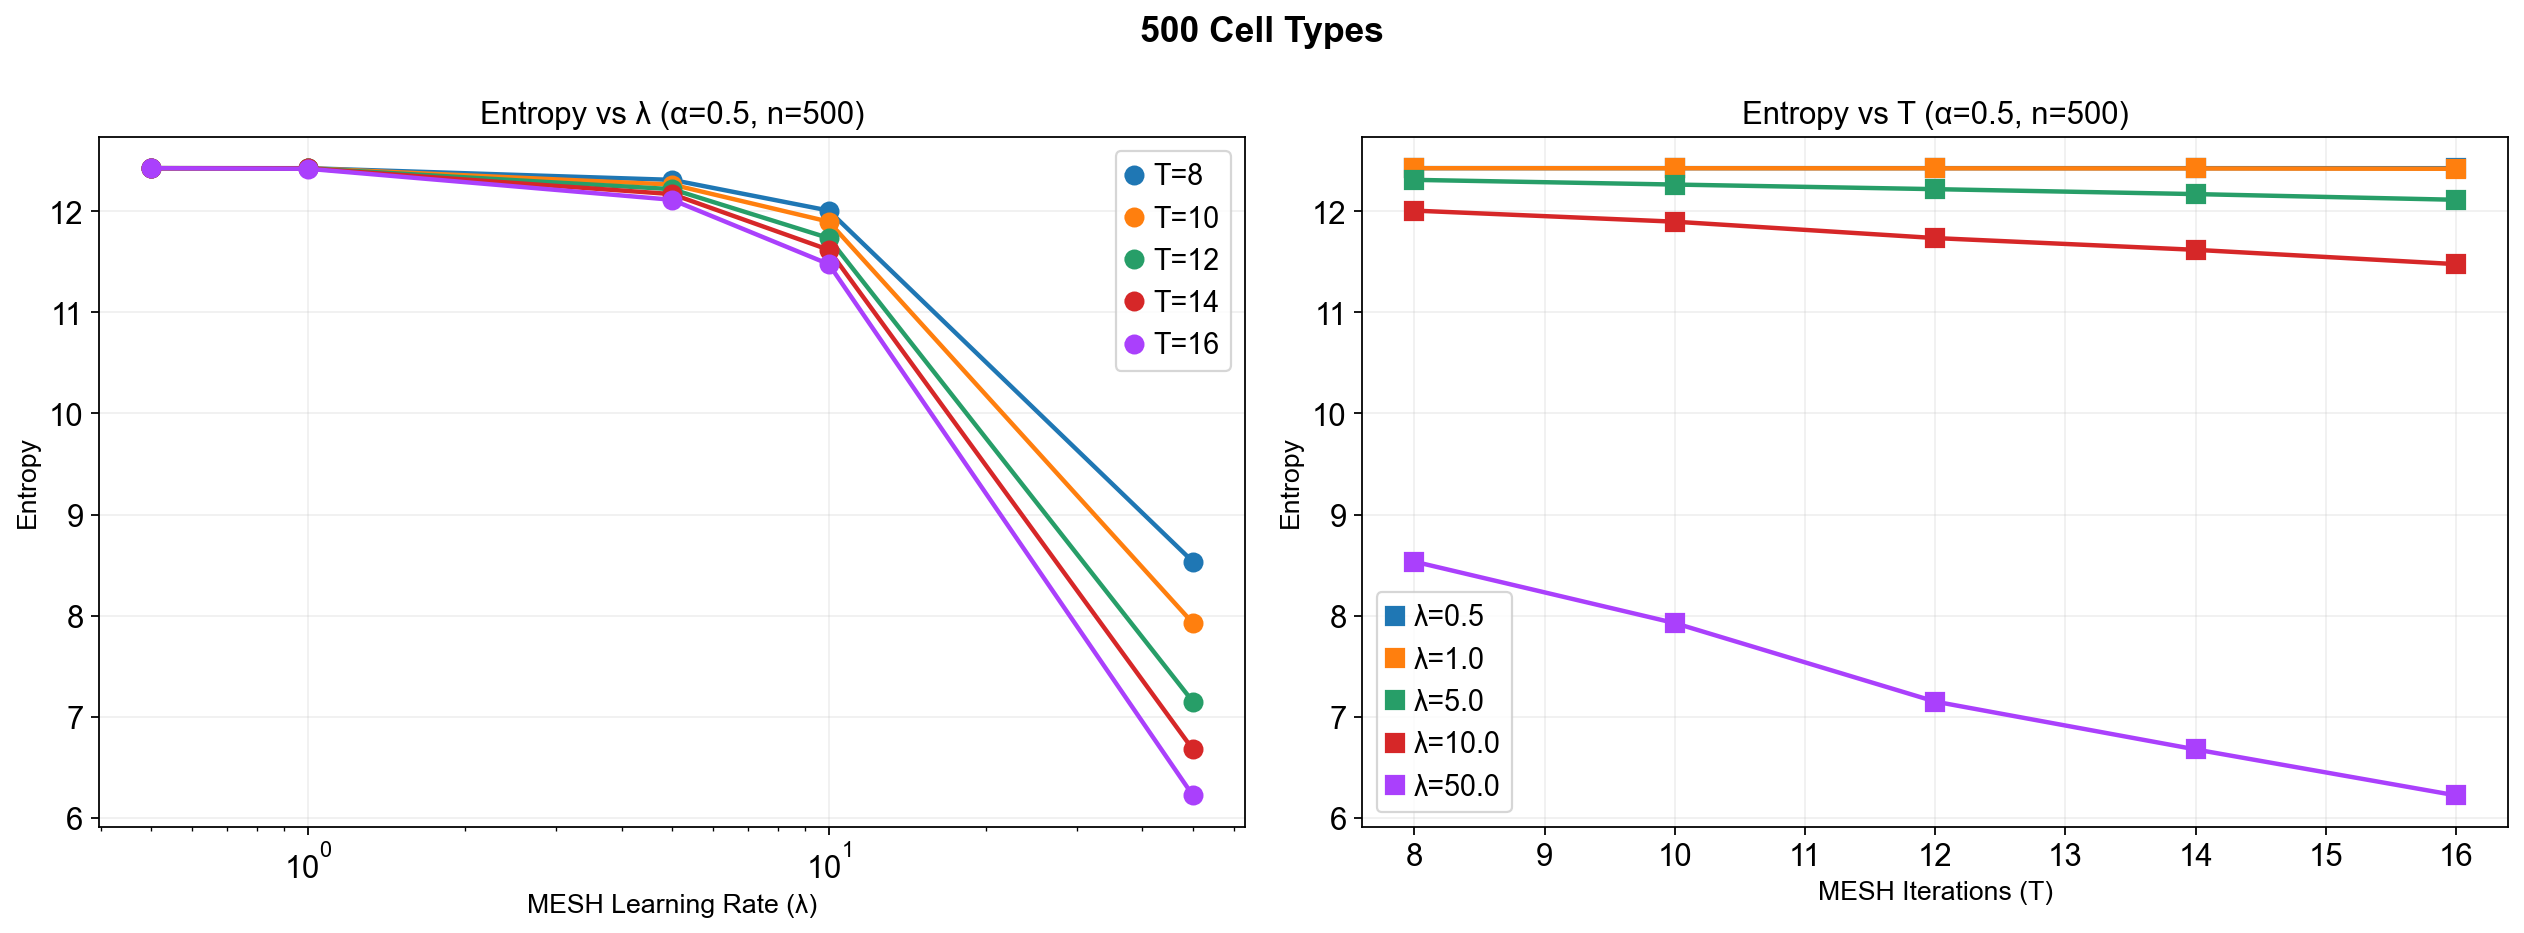

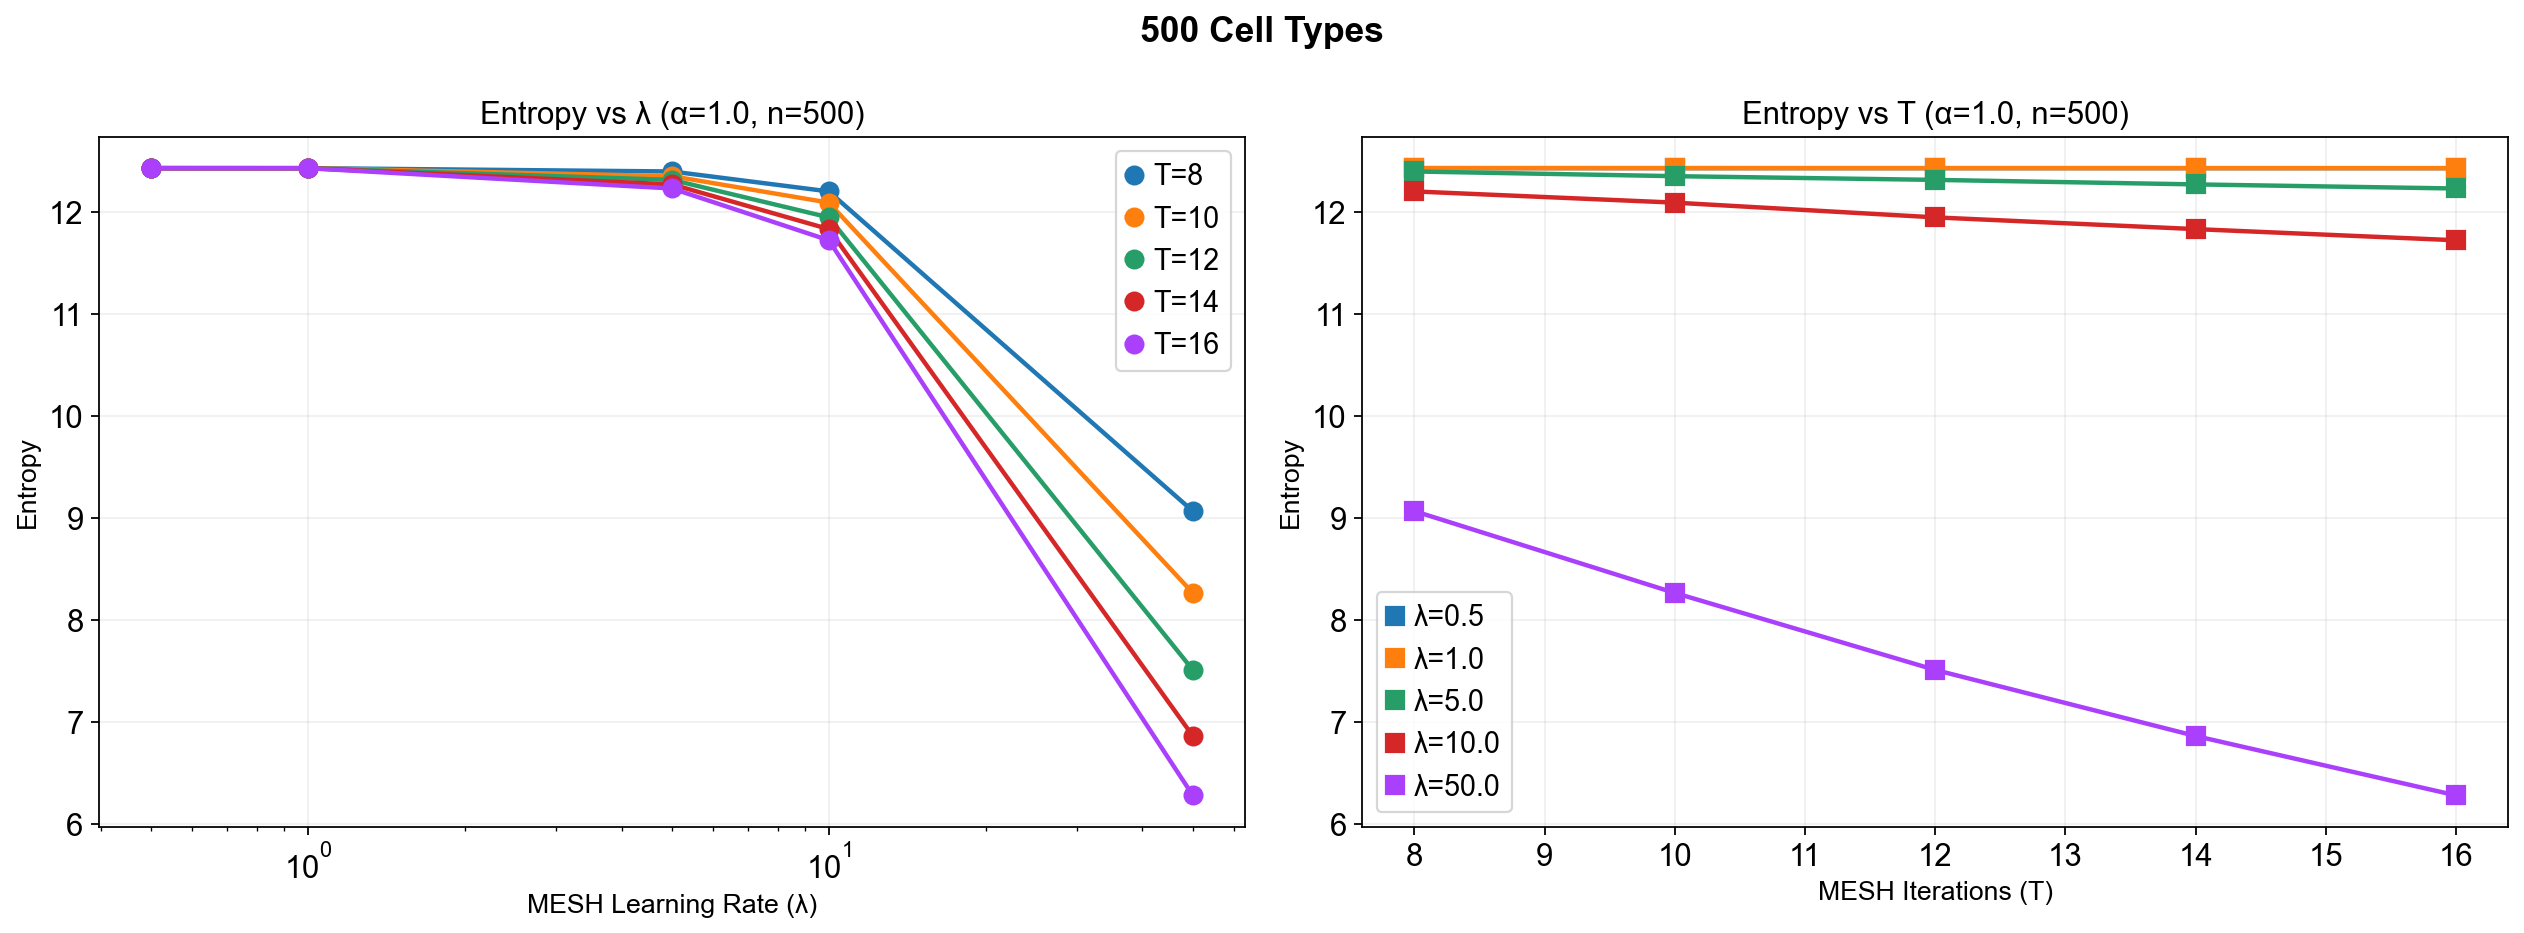

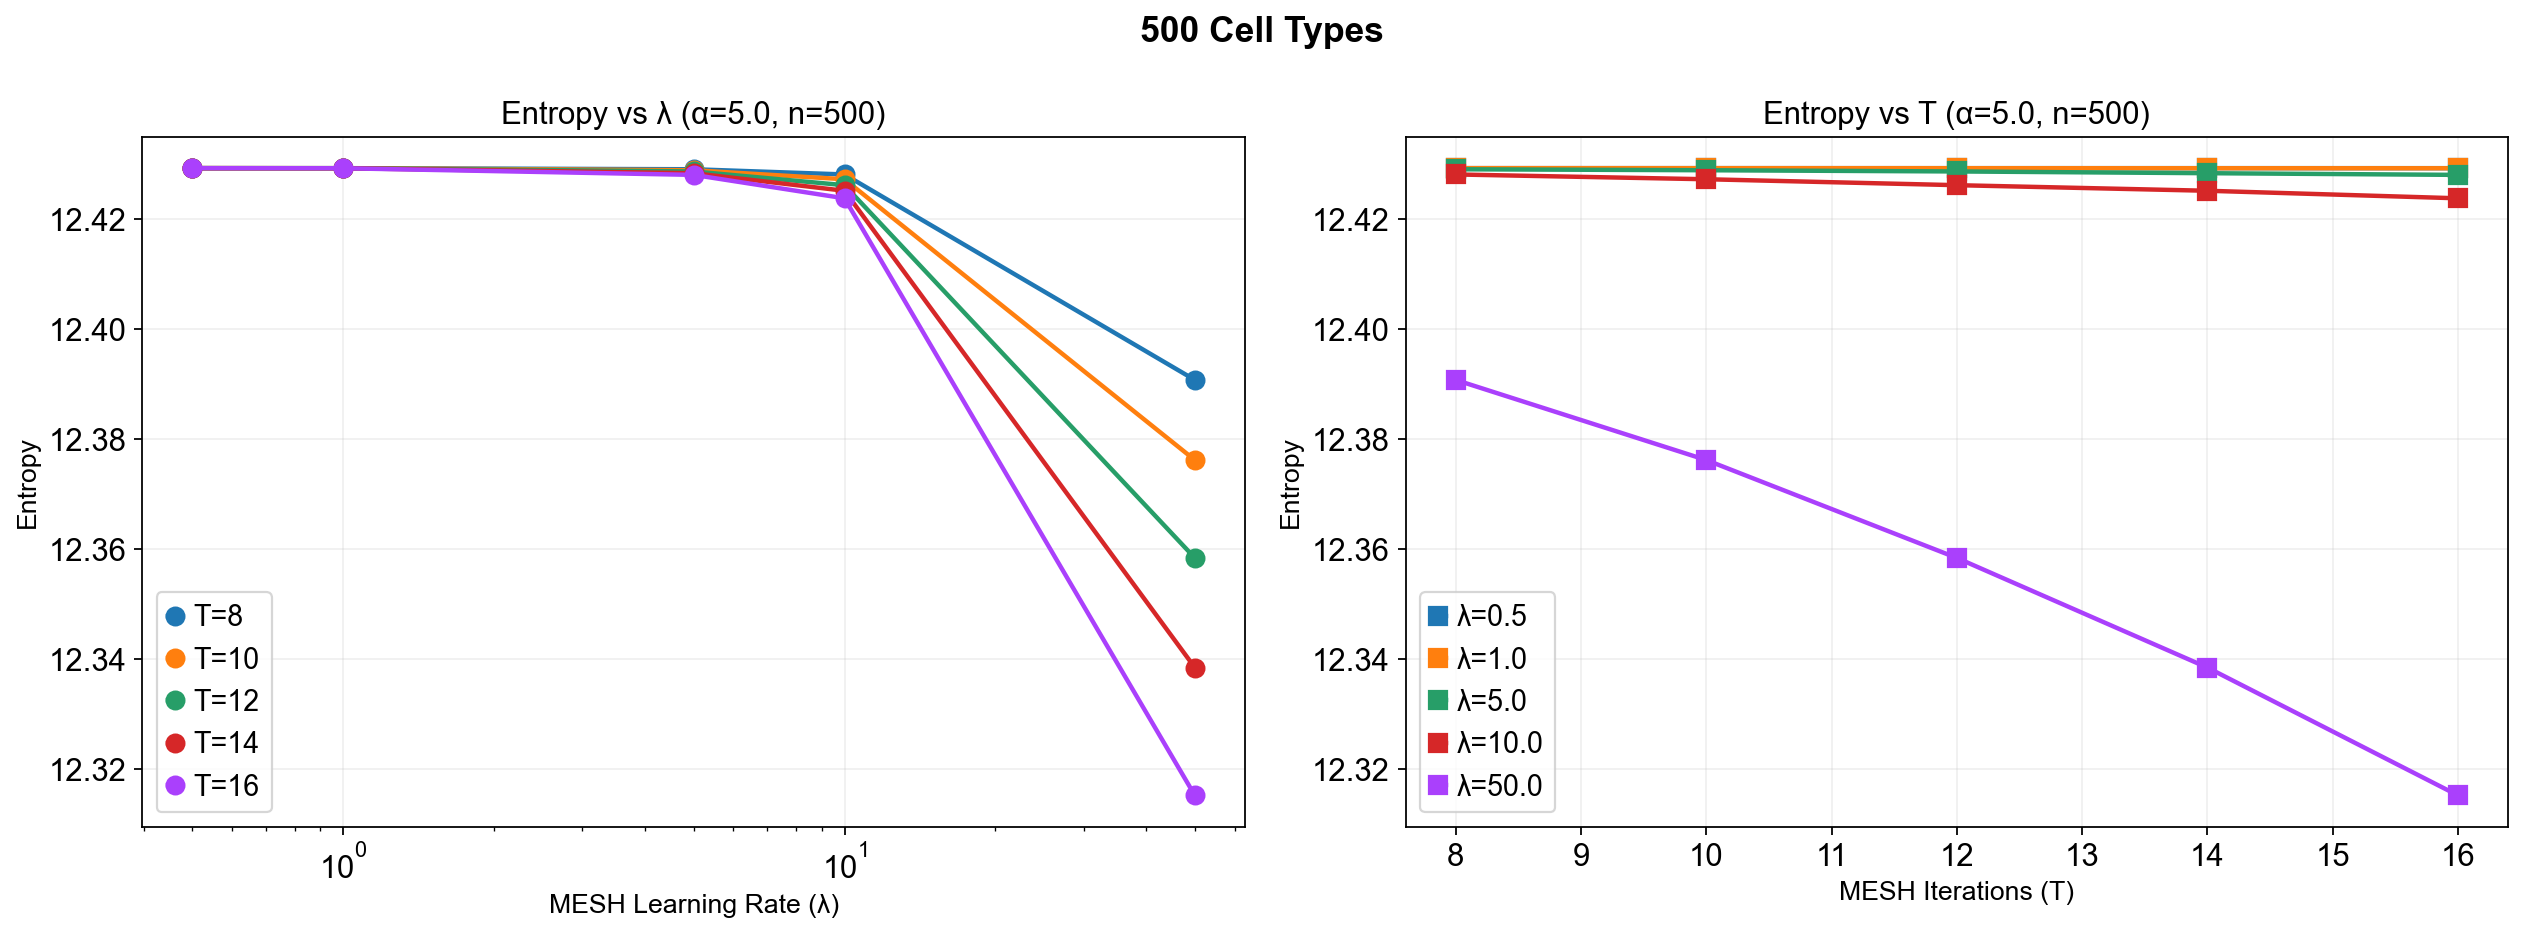

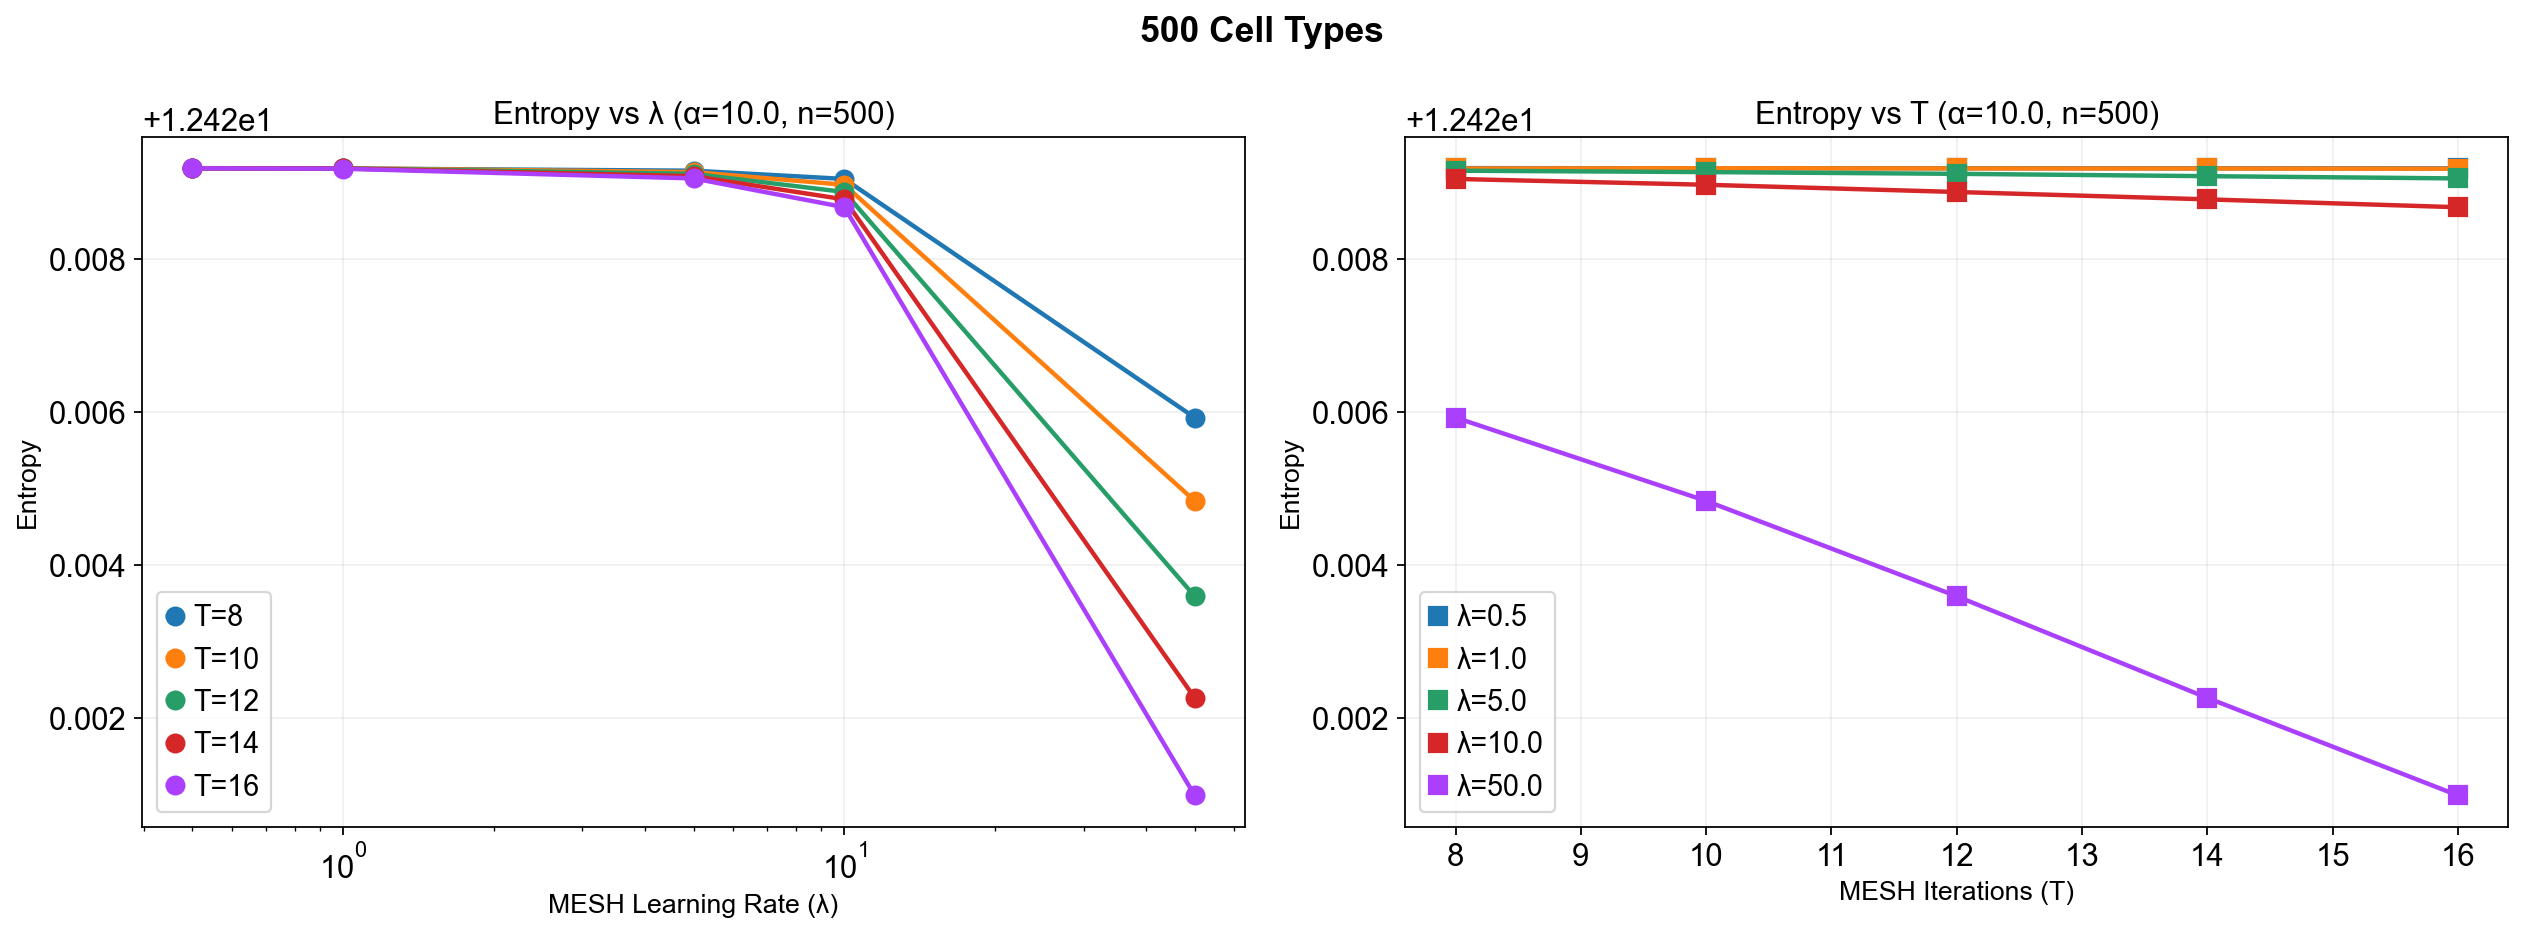


MANUAL ELBOW SELECTION REQUIRED
Please review the generated plots and fill in the elbow points below.
Copy and modify the following code with your selections:

# 20 cell types
all_selections[20][0].update({'elbow_lambda': None, 'elbow_T': None})  # α=0.1
all_selections[20][1].update({'elbow_lambda': None, 'elbow_T': None})  # α=0.5
all_selections[20][2].update({'elbow_lambda': None, 'elbow_T': None})  # α=1.0
all_selections[20][3].update({'elbow_lambda': None, 'elbow_T': None})  # α=5.0
all_selections[20][4].update({'elbow_lambda': None, 'elbow_T': None})  # α=10.0

# 50 cell types
all_selections[50][0].update({'elbow_lambda': None, 'elbow_T': None})  # α=0.1
all_selections[50][1].update({'elbow_lambda': None, 'elbow_T': None})  # α=0.5
all_selections[50][2].update({'elbow_lambda': None, 'elbow_T': None})  # α=1.0
all_selections[50][3].update({'elbow_lambda': None, 'elbow_T': None})  # α=5.0
all_selections[50][4].update({'elbow_lambda': None, 'elbow_T': None})  # α=10.0

# 100 cell ty

In [3]:
print("STEP 1: Generating parameter sweeps and elbow curves...")
all_results, all_selections, all_distance_matrices = run_multi_scale_parameter_selection()

print("\n" + "="*80)
print("IMPORTANT: Manual selection required!")
print("="*80)
print("1. Review the generated elbow curve plots in ./Parameter_Selection/")
print("2. Identify the elbow points for λ and T for each α")
print("3. Fill in the selections below and run Step 2")
print("="*80)

In [4]:
# Example selections (replace with your actual elbow points):

# 20 cell types
all_selections[20][0].update({'elbow_lambda': 5.0, 'elbow_T': 6})  # α=0.1
all_selections[20][1].update({'elbow_lambda': 5.0, 'elbow_T': 8})  # α=0.5
all_selections[20][2].update({'elbow_lambda': 5.0, 'elbow_T': 8})  # α=1.0
all_selections[20][3].update({'elbow_lambda': None, 'elbow_T': None})  # α=5.0
all_selections[20][4].update({'elbow_lambda': None, 'elbow_T': None})  # α=10.0

# 50 cell types
all_selections[50][0].update({'elbow_lambda': 5.0, 'elbow_T': 14})  # α=0.1
all_selections[50][1].update({'elbow_lambda': 10.0, 'elbow_T': 10})  # α=0.5
all_selections[50][2].update({'elbow_lambda': 10.0, 'elbow_T': 12})  # α=1.0
all_selections[50][3].update({'elbow_lambda': None, 'elbow_T': None})  # α=5.0
all_selections[50][4].update({'elbow_lambda': None, 'elbow_T': None})  # α=10.0

# 100 cell types
all_selections[100][0].update({'elbow_lambda': 10.0, 'elbow_T': 14})  # α=0.1
all_selections[100][1].update({'elbow_lambda': 10.0, 'elbow_T': 16})  # α=0.5
all_selections[100][2].update({'elbow_lambda': 10.0, 'elbow_T': 16})  # α=1.0
all_selections[100][3].update({'elbow_lambda': None, 'elbow_T': None})  # α=5.0
all_selections[100][4].update({'elbow_lambda': None, 'elbow_T': None})  # α=10.0

# 200 cell types
all_selections[200][0].update({'elbow_lambda': 10.0, 'elbow_T': 14})  # α=0.1
all_selections[200][1].update({'elbow_lambda': 10.0, 'elbow_T': 16})  # α=0.5
all_selections[200][2].update({'elbow_lambda': 10.0, 'elbow_T': 16})  # α=1.0
all_selections[200][3].update({'elbow_lambda': None, 'elbow_T': None})  # α=5.0
all_selections[200][4].update({'elbow_lambda': None, 'elbow_T': None})  # α=10.0

# 500 cell types
all_selections[500][0].update({'elbow_lambda': 50.0, 'elbow_T': 14})  # α=0.1
all_selections[500][1].update({'elbow_lambda': None, 'elbow_T': None})  # α=0.5
all_selections[500][2].update({'elbow_lambda': None, 'elbow_T': None})   # α=1.0
all_selections[500][3].update({'elbow_lambda': None, 'elbow_T': None})  # α=5.0
all_selections[500][4].update({'elbow_lambda': None, 'elbow_T': None})  # α=10.0



STEP 2: Applying manual selections...

Processing 20 cell types

TRANSPORT COSTS FOR EACH α (20 types)
α =  0.100: Transport Cost = 0.004117 (λ=5.0, T=6, Entropy=2.9986, Sparsity=0.950)
α =  0.500: Transport Cost = 0.004115 (λ=5.0, T=8, Entropy=2.9962, Sparsity=0.950)
α =  1.000: Transport Cost = 0.004902 (λ=5.0, T=8, Entropy=3.1141, Sparsity=0.950)

OPTIMAL PARAMETERS FOR 20 TYPES
α = 0.5, λ = 5.0, T = 8
Transport Cost: 0.004115
Entropy: 2.9962
Sparsity: 0.950


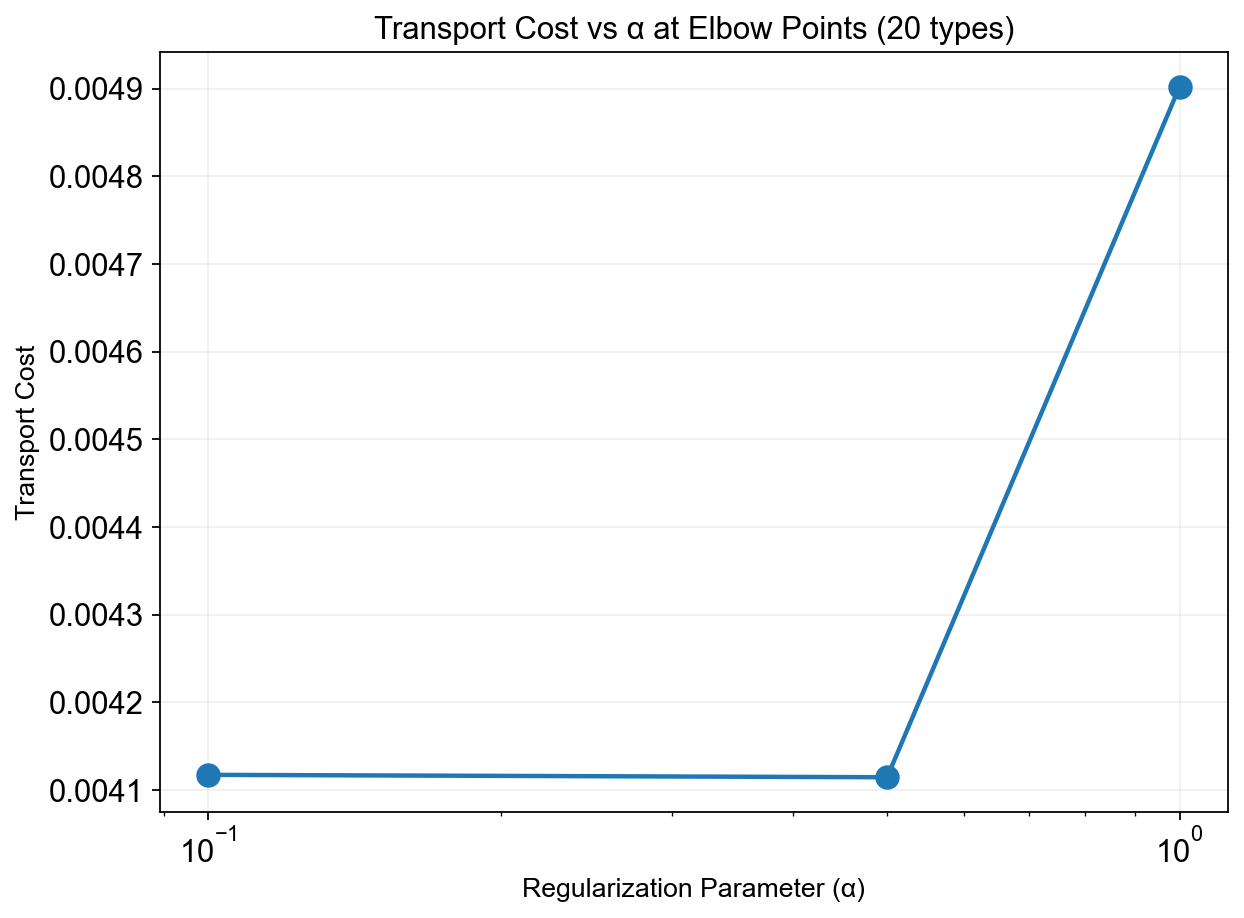


Final verification:
  Entropy: 2.9964
  Sparsity: 0.950
  Transport Cost: 0.004115

Processing 50 cell types

TRANSPORT COSTS FOR EACH α (50 types)
α =  0.100: Transport Cost = 0.004718 (λ=5.0, T=14, Entropy=3.9166, Sparsity=0.980)
α =  0.500: Transport Cost = 0.004715 (λ=10.0, T=10, Entropy=3.9121, Sparsity=0.980)
α =  1.000: Transport Cost = 0.004726 (λ=10.0, T=12, Entropy=3.9172, Sparsity=0.980)

OPTIMAL PARAMETERS FOR 50 TYPES
α = 0.5, λ = 10.0, T = 10
Transport Cost: 0.004715
Entropy: 3.9121
Sparsity: 0.980


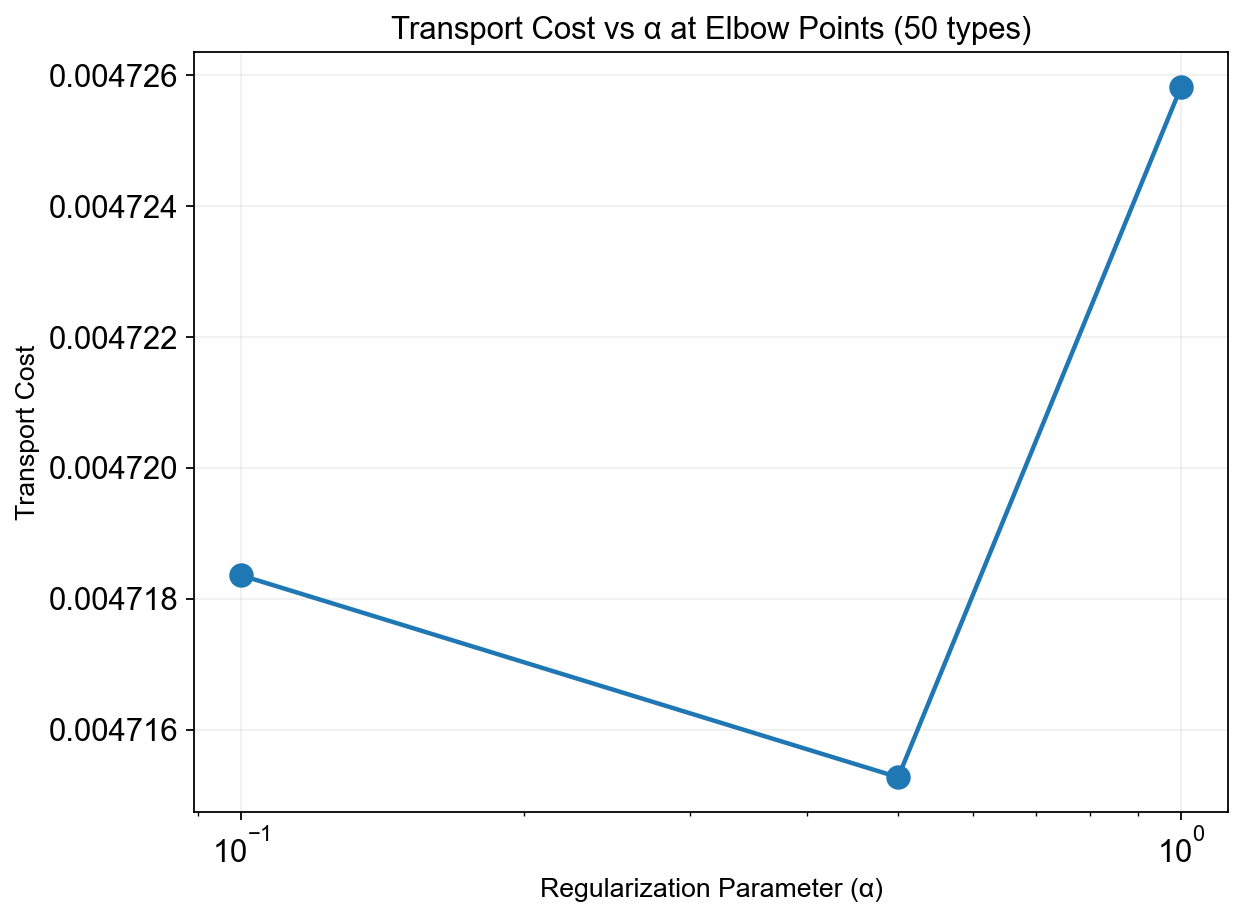


Final verification:
  Entropy: 3.9120
  Sparsity: 0.980
  Transport Cost: 0.004715

Processing 100 cell types

TRANSPORT COSTS FOR EACH α (100 types)
α =  0.100: Transport Cost = 0.005815 (λ=10.0, T=14, Entropy=4.6264, Sparsity=0.990)
α =  0.500: Transport Cost = 0.005904 (λ=10.0, T=16, Entropy=4.6899, Sparsity=0.990)
α =  1.000: Transport Cost = 0.006981 (λ=10.0, T=16, Entropy=5.2046, Sparsity=0.990)

OPTIMAL PARAMETERS FOR 100 TYPES
α = 0.1, λ = 10.0, T = 14
Transport Cost: 0.005815
Entropy: 4.6264
Sparsity: 0.990


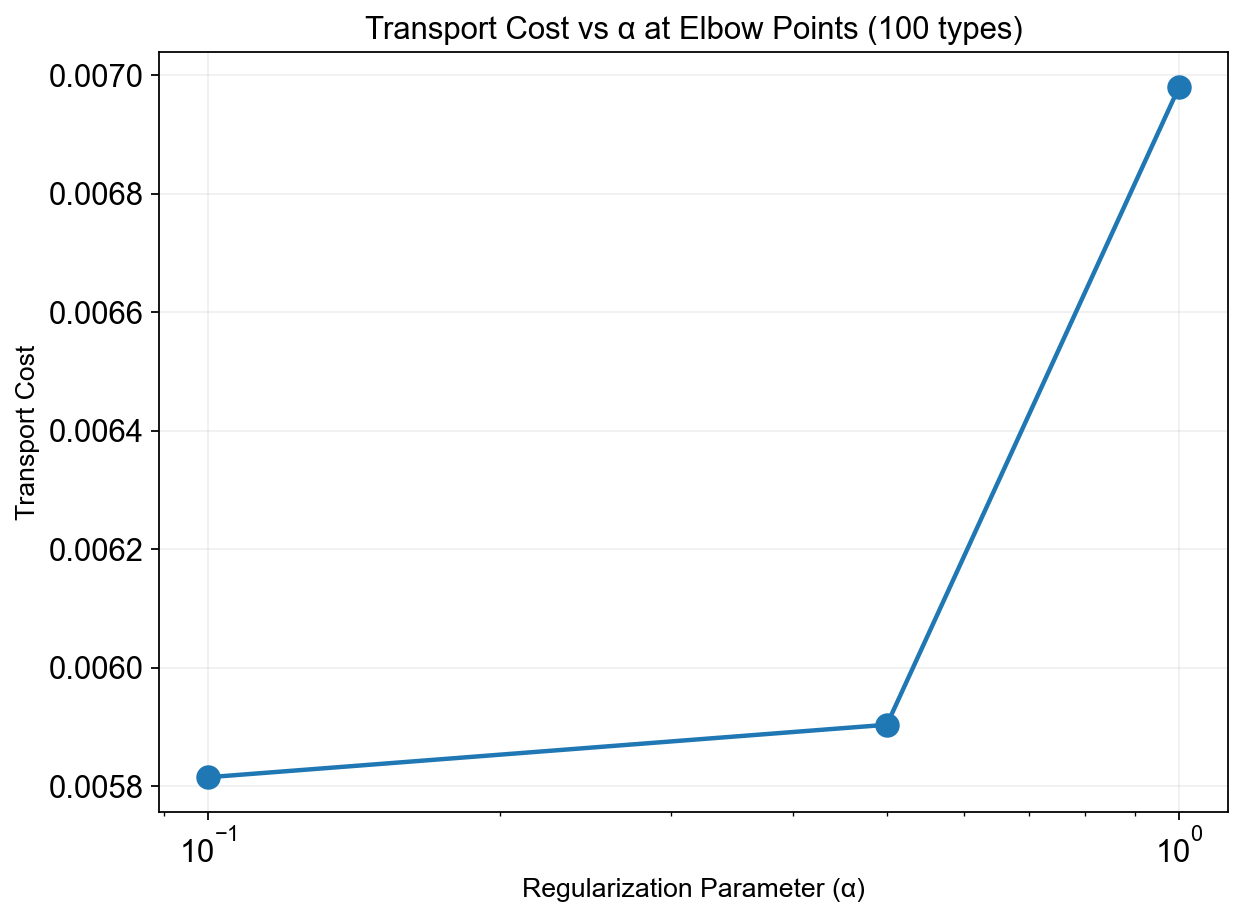


Final verification:
  Entropy: 4.6246
  Sparsity: 0.990
  Transport Cost: 0.005811

Processing 200 cell types

TRANSPORT COSTS FOR EACH α (200 types)
α =  0.100: Transport Cost = 0.006680 (λ=10.0, T=14, Entropy=5.7115, Sparsity=0.995)
α =  0.500: Transport Cost = 0.012244 (λ=10.0, T=16, Entropy=7.3304, Sparsity=0.997)
α =  1.000: Transport Cost = 0.015073 (λ=10.0, T=16, Entropy=7.9238, Sparsity=0.997)

OPTIMAL PARAMETERS FOR 200 TYPES
α = 0.1, λ = 10.0, T = 14
Transport Cost: 0.006680
Entropy: 5.7115
Sparsity: 0.995


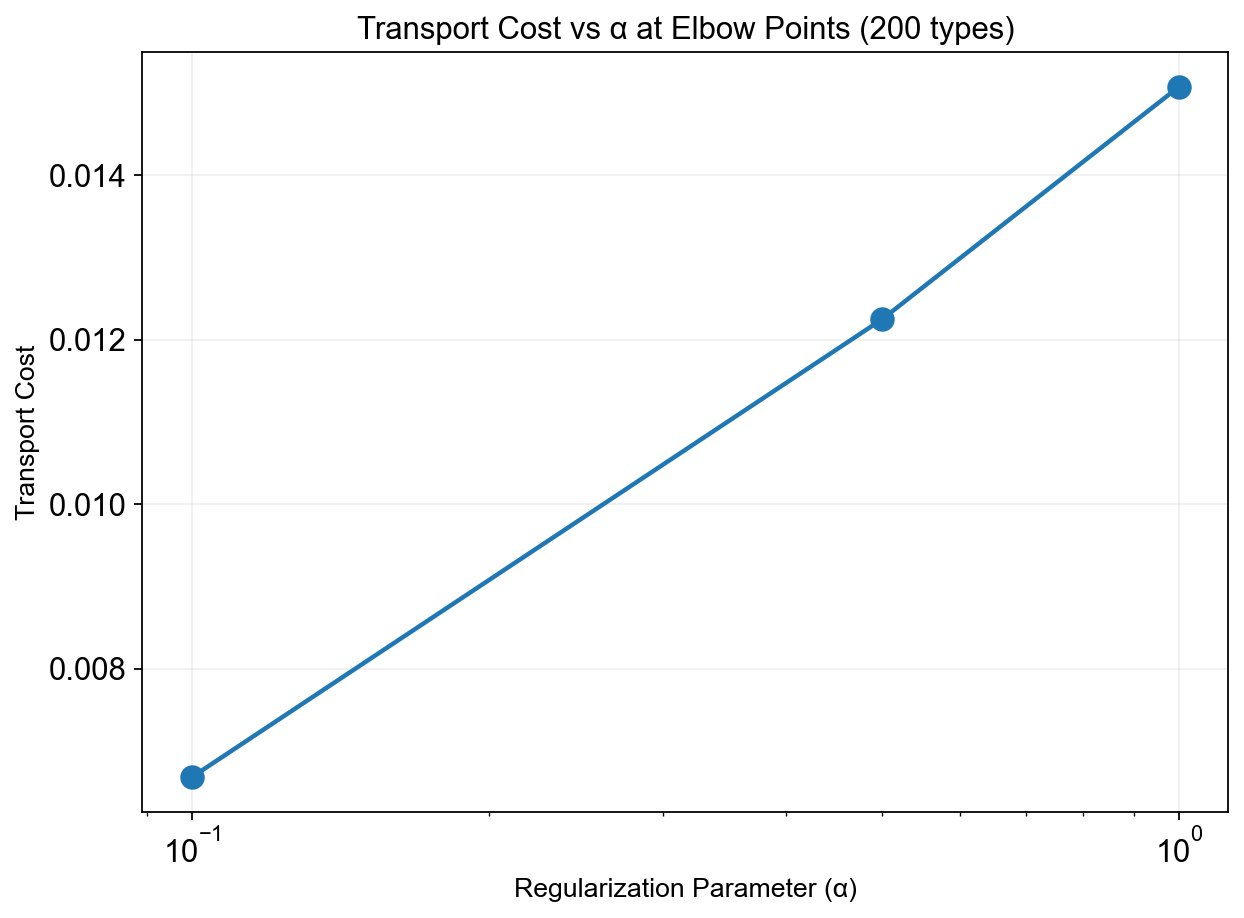


Final verification:
  Entropy: 5.6940
  Sparsity: 0.995
  Transport Cost: 0.006647

Processing 500 cell types

TRANSPORT COSTS FOR EACH α (500 types)
α =  0.100: Transport Cost = 0.006367 (λ=50.0, T=14, Entropy=6.2194, Sparsity=0.998)

OPTIMAL PARAMETERS FOR 500 TYPES
α = 0.1, λ = 50.0, T = 14
Transport Cost: 0.006367
Entropy: 6.2194
Sparsity: 0.998

Final verification:
  Entropy: 6.2204
  Sparsity: 0.998
  Transport Cost: 0.006368


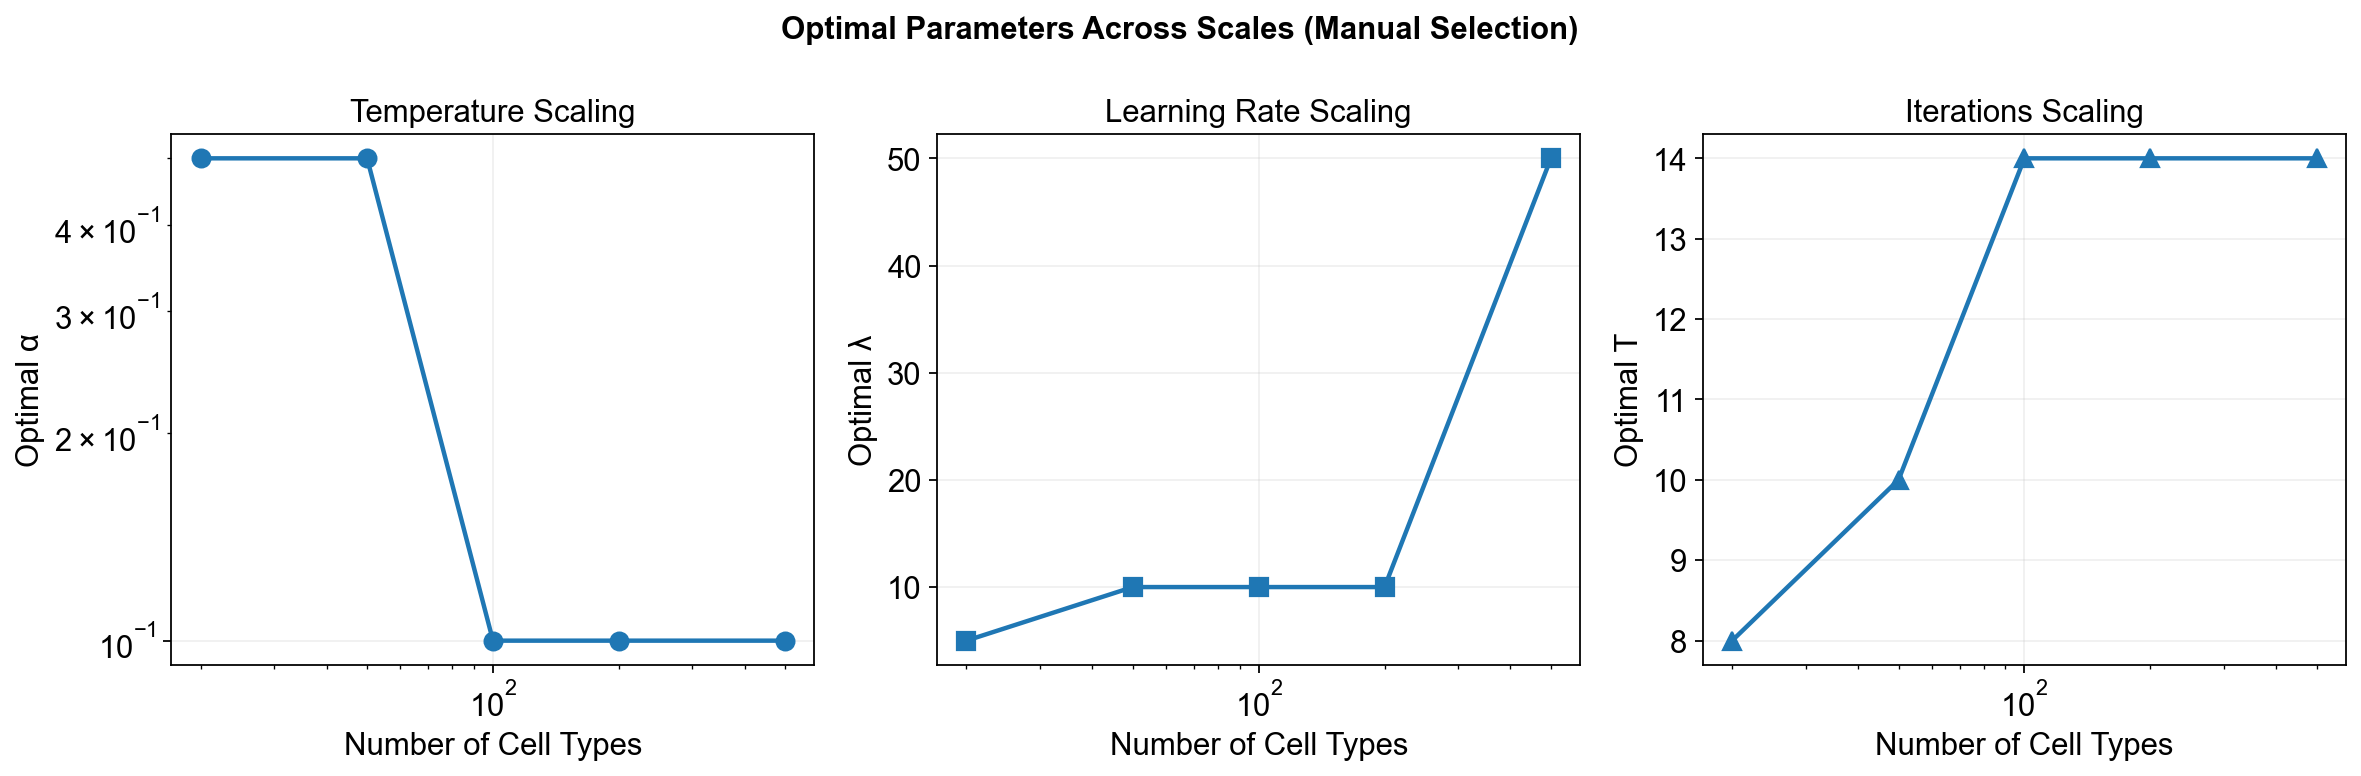


FINAL OPTIMAL PARAMETERS (for use in benchmarking)
20 types: α=0.5000, λ=5.0, T=8
50 types: α=0.5000, λ=10.0, T=10
100 types: α=0.1000, λ=10.0, T=14
200 types: α=0.1000, λ=10.0, T=14
500 types: α=0.1000, λ=50.0, T=14


In [5]:
print("\nSTEP 2: Applying manual selections...")
optimal_params_all = apply_all_selections_and_benchmark(
    all_results, all_selections, all_distance_matrices
)

print("\n" + "="*80)
print("FINAL OPTIMAL PARAMETERS (for use in benchmarking)")
print("="*80)

# Create a simplified parameter dictionary for benchmarking
benchmark_params = {}
for n_types, params in optimal_params_all.items():
    benchmark_params[n_types] = {
        'temperature': params['alpha'],
        'mesh_lr': params['mesh_lr'],
        'n_mesh_iters': int(params['mesh_iters']),
        'n_sh_iters': 5
    }
    print(f"{n_types} types: α={params['alpha']:.4f}, λ={params['mesh_lr']:.1f}, T={params['mesh_iters']}")


In [6]:
import os
output_dir = "./Parameter_Selection"
os.makedirs(output_dir, exist_ok=True)

# Save as JSON
with open(f"{output_dir}/optimal_parameters.json", 'w') as f:
    json.dump(benchmark_params, f, indent=2)
print(f"\nSaved parameters to {output_dir}/optimal_parameters.json")

# Save as pickle (preserves exact numeric types)
with open(f"{output_dir}/optimal_parameters.pkl", 'wb') as f:
    pickle.dump(benchmark_params, f)
print(f"Saved parameters to {output_dir}/optimal_parameters.pkl")

print("\n" + "="*80)
print("Parameters saved successfully!")
print("Use these files in benchmarking scripts.")
print("="*80)


Saved parameters to ./Parameter_Selection/optimal_parameters.json
Saved parameters to ./Parameter_Selection/optimal_parameters.pkl

Parameters saved successfully!
Use these files in benchmarking scripts.
